# Análisis de cambio semánticos

In [1]:
# Importar librería
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import pickle
import os
import re
import random as rn
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import bootstrap
import matplotlib.pyplot as plt
import itertools

from gensim.models import Word2Vec
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
tqdm.pandas()

from ast import literal_eval

In [2]:
# Configurar
load_dotenv() # Cargar las variables de entorno del archivo .env
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") # Acceder a las variables de entorno
modelo_dir =  RESULTADOS_DIR+ '/archivos_out/modelos_swmwosge_1008211100'
pd.set_option('display.max_colwidth', None)

Se selecciona para analizar el modelo de procrustes

In [3]:
basename = 'procrustes'
iteracion = 50
tam_vector = 100

In [4]:
# estabilidad_procrustes_iter10_tam50
selected_topics_df = pd.read_csv(
    modelo_dir+'/estabilidad_procrustes/estabilidad_'+basename+'_iter'+str(iteracion)+'_tam'+str(tam_vector)+'.csv',
    converters={'par_periodo': literal_eval})

selected_topics_df.head(5)

,iteracion,par_periodo,palabra,similaridad_semantica,cantidad_palabras_comun,top10_vecindad_t1,top10_vecindad_t2
0,17,"(2014, 2019)",accion,0.162480,461,"[('comunitario', 0.6701722741127014), ('julio', 0.6596931219100952), ('judicial', 0.648351788520813), ('nacimiento', 0.6341621279716492), ('valor', 0.6208097338676453), ('doctor', 0.6187101602554321), ('psicologico', 0.5932990312576294), ('premio', 0.5850068926811218), ('mental', 0.5469589233398438), ('listado', 0.5299479961395264)]","[('celula', 0.6882323622703552), ('epidemiologico', 0.6513953804969788), ('organo', 0.6446195840835571), ('promover', 0.6213864088058472), ('recoleccion', 0.5605630278587341), ('padecer', 0.5597422122955322), ('proteina', 0.558529794216156), ('aplv', 0.5509136319160461), ('artriti', 0.5387381911277771), ('donacion', 0.5236662030220032)]"
1,28,"(2009, 2014)",basico,0.164258,633,"[('ninez', 0.6785711646080017), ('laboratorio', 0.6778303980827332), ('fincini', 0.6393669843673706), ('ganancia', 0.6318456530570984), ('ingreso', 0.6188706755638123), ('menor', 0.5986019372940063), ('animal', 0.5918625593185425), ('utilizacion', 0.5910429954528809), ('distribucion', 0.5808166861534119), ('calidad', 0.5791724920272827)]","[('reduccion', 0.7098894715309143), ('objeto', 0.6683726906776428), ('precio', 0.6343139410018921), ('recien', 0.6152833700180054), ('nacido', 0.6110486388206482), ('equipo', 0.5789337158203125), ('situacion', 0.557402491569519), ('primaria', 0.5468682646751404), ('argentina', 0.5458145141601562), ('exposicion', 0.5411607623100281)]"
2,27,"(2009, 2014)",declaracion,0.164947,633,"[('jujuy', 0.6901476383209229), ('valle', 0.6564000248908997), ('rioja', 0.6363512277603149), ('accion', 0.6304577589035034), ('natural', 0.6200164556503296), ('departamento', 0.6080764532089233), ('vital', 0.6074527502059937), ('plazo', 0.5891237258911133), ('chaco', 0.5810564160346985), ('epidemiologico', 0.5787025690078735)]","[('prepagar', 0.6943920254707336), ('valor', 0.6674725413322449), ('suspension', 0.6162013411521912), ('medicina', 0.6089933514595032), ('marco', 0.6060857772827148), ('afiliado', 0.5984249711036682), ('inssjp', 0.5914453864097595), ('listado', 0.5912353992462158), ('maternidad', 0.5652633905410767), ('requisito', 0.5630848407745361)]"
3,42,"(2014, 2019)",dispositivo,0.167827,461,"[('nocivo', 0.7343155741691589), ('electronico', 0.6881446242332458), ('similar', 0.6654688715934753), ('dato', 0.6024550795555115), ('transgenico', 0.580215334892273), ('necesario', 0.5762345790863037), ('digital', 0.5729315876960754), ('implementacion', 0.5455357432365417), ('efecto', 0.5406650304794312), ('receta', 0.5310193300247192)]","[('tecnologico', 0.6678495407104492), ('minimo', 0.6082873344421387), ('concurrencia', 0.5716546177864075), ('desfibrilador', 0.5689347982406616), ('subitar', 0.5670633316040039), ('oftalmologico', 0.5669408440589905), ('instalacion', 0.5386484861373901), ('examen', 0.507822573184967), ('comprendido', 0.5065670013427734), ('cartel', 0.4893917739391327)]"
4,41,"(2014, 2019)",dispositivo,0.176257,461,"[('nocivo', 0.7437414526939392), ('electronico', 0.6668277978897095), ('similar', 0.6574527621269226), ('dato', 0.5713828802108765), ('necesario', 0.5681675672531128), ('efecto', 0.5635452270507812), ('transgenico', 0.5508639216423035), ('leches', 0.5361123085021973), ('fabricacion', 0.5357250571250916), ('medicamentosa', 0.530888557434082)]","[('tecnologico', 0.6613434553146362), ('minimo', 0.6292621493339539), ('subitar', 0.6030382513999939), ('desfibrilador', 0.5431399345397949), ('instalacion', 0.5388169884681702), ('concurrencia', 0.5351226925849915), ('oftalmologico', 0.5286857485771179), ('cartel', 0.495991051197052), ('comprendido', 0.488023042678833), ('aplicacion', 0.48645636439323425)]"


In [5]:
selected_topics_df.describe() # Estadística

,iteracion,similaridad_semantica,cantidad_palabras_comun
count,54700.000000,54700.000000,54700.000000
mean,24.500000,0.660609,560.521024
std,14.431002,0.137131,84.931230
min,0.000000,0.162480,461.000000
25%,12.000000,0.573917,461.000000
50%,24.500000,0.672961,633.000000
75%,37.000000,0.759214,633.000000
max,49.000000,0.953947,633.000000


Se realizaron 50 ejecuciones independientes del enfoque Procrustes, cada una con una semilla aleatoria distinta. En cada iteración, se seleccionaron las 300 palabras con mayor cambio semántico entre los pares de períodos comparados, considerando únicamente aquellas con al menos 5 ocurrencias en alguno de los dos períodos de cinco años.

Posteriormente, se calculó la similaridad semantica promedio (medida de estabilidad del modelo) para cada palabra identificada en cada par de periodos comparados. Este valor fue estimado junto con sus respectivos intervalos de confianza del 95%, utilizando el método bootstrap.

In [6]:
n = 300
at_least_in_any_decade = 5
pares_periodo = [ (2009, 2014),(2014, 2019)]
topn_periodo = {}

for par_periodo in pares_periodo:
    df =  selected_topics_df[
        selected_topics_df['par_periodo'] == par_periodo
    ].copy()
    
    
    frecPer1 = pd.read_csv(RESULTADOS_DIR+'/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(par_periodo[0])+'.csv')
    frecPer2 = pd.read_csv(RESULTADOS_DIR+'/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(par_periodo[1])+'.csv')
    frecPer1.columns = ['palabra', 'frec1', 'porc1']
    frecPer2.columns = ['palabra', 'frec2', 'porc2']
    #print(frecPer2.shape)
    topn_all_df = []

    for iter in range(iteracion):
        #print(iter)
        df_topn = df[(df.iteracion==iter)]
        #controlar frec
        #display(df_topn)
        df_topn = df_topn.merge(frecPer1, how='left', on='palabra')
        df_topn = df_topn.merge(frecPer2, how='left', on='palabra')
        df_topn['max_freq_of_any_decade'] = df_topn[['frec1', 'frec2']].max(axis=1)
        df_topn.drop(['frec1', 'frec2', 'porc1', 'porc2'], axis=1, inplace=True) 
        df_topn = df_topn.loc[df_topn.max_freq_of_any_decade>= at_least_in_any_decade].head(n)
        df_topn = df_topn.sort_values('similaridad_semantica', ascending=True).head(n)
        #display(df_topn)
        topn_all_df.append(df_topn)
    
    topn_periodo[par_periodo] = pd.concat(topn_all_df, ignore_index=True)    


#### Intersección promedio
Por el enfoque Procruste para cada par de periodos de 5 años:
¿Cuál es la similaridad semantica promedio (medida de estabilidad del modelo) de los top 300 palabras de las 50 ejecuciones para cada par de periodos comparados con intervalos de confianza del 95% calculados mediante el método bootstrap? 


In [7]:
def confidence_intervals(data):
    res = bootstrap((data,), np.mean, confidence_level=0.95)
    return (res.confidence_interval.low, res.confidence_interval.high)

In [8]:
topn_periodo_all = topn_periodo.copy() # copiar

In [9]:
for par_periodo in pares_periodo: 
    display(topn_periodo[par_periodo].shape)
    df = topn_periodo[par_periodo].copy()
    data = df['palabra'].value_counts().reset_index()
    data = data[data['count']>2]
    pal_lista = list(data['palabra'].unique())
    df = df[df['palabra'].isin(pal_lista)]
    df['vt1'] = df['top10_vecindad_t1'].apply(lambda x: [ peso[0] for peso in eval(x) ])
    df['vt2'] = df['top10_vecindad_t2'].apply(lambda x: [ peso[0] for peso in eval(x) ])
    #df = df[['par_periodo', 'palabra', 'similaridad_semantica']].groupby(['par_periodo', 'palabra']).agg(['mean', confidence_intervals]).reset_index()
    df = df[['par_periodo', 'palabra', 'similaridad_semantica','vt1','vt2']].groupby(['par_periodo', 'palabra']).agg({
        'similaridad_semantica': ['mean',confidence_intervals],
        'vt1': [ lambda listas: set.intersection(*map(set, listas))],
        'vt2': [ lambda listas: set.intersection(*map(set, listas))]
    }).reset_index()

    #df.sort_values(by='par_periodo', inplace=True)
    df.columns = [
    '_'.join(filter(None, x))
    for x in df.columns.to_flat_index() 
    ]
     	
    df.rename(columns={'vt1_<lambda>': 'vt1_top10', 'vt2_<lambda>': 'vt2_top10'}, inplace=True)
    topn_periodo[par_periodo] = df

    
  
  


(15000, 8)

(15000, 8)

### Cambios semánticos  

#### Identificar las palabras con cambio semántico importante y moderado


Basado en los resultados de similitud coseno o distancia entre embeddings alineados, se establecio umbrales:

* Cambio importante: similitud coseno <= 0.3
* Cambio moderado:  0.3 y 0.5

Identificar las palabras más estables en su cambio semántico, es decir, aquellas que aparecen consistentemente como cambiantes.


* si Distancia = 1 - similitud coseno (sc)
Interpretación
* dist ~ 0.0 (sc ~ 1)	 La palabra no cambió su significado
* dist ~ 0.5 (sc ~ 0.5)  Cambio moderado
* dist > 0.7 (sc <= 0.3) Cambio fuerte (usos muy distintos)


In [10]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Convertir datos en DataFrame para visualización
def plot_heatmap(cambios_df, title, top = 10):
    #words, values = zip(*changed_words[:top])  # Tomamos el top 10
    #df = pd.DataFrame({"Palabra": words, "Cambio Semántico": values})
    df = cambios_df.copy()
    plt.figure(figsize=(8, 5))
    sns.heatmap(df.set_index("palabra").T, cmap="Reds", annot=True, fmt=".2f", linewidths=0.5)
    plt.title(title + " Top "+str(top))
    plt.show()



dist > 0.7 (sc <= 0.3) Cambio fuerte (usos muy distintos)


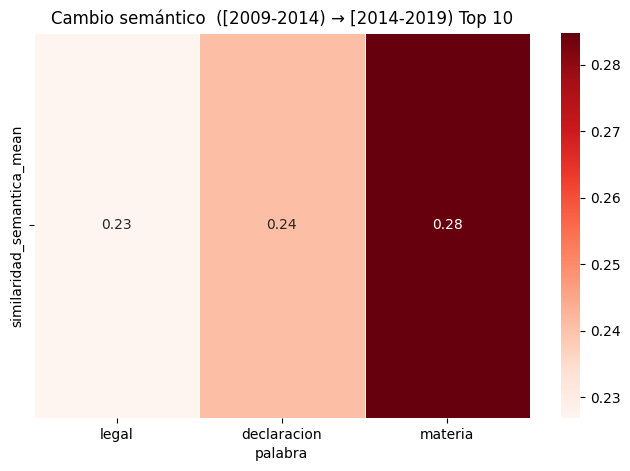

TOP 10 Palabras: ['legal' 'declaracion' 'materia']


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10
185,"(2009, 2014)",legal,0.226934,"(0.22002384660263957, 0.23402394056119352)","{norma, loteria, colaborador, odontologia, auxiliar, musicoterapia}","{embarazo, monodroga, misoprostol, droga}"
81,"(2009, 2014)",declaracion,0.240741,"(0.23132365204190666, 0.25030950875089053)","{departamento, chaco, natural, jujuy, valle, rioja, accion}","{marco, prepagar, valor, suspension}"
196,"(2009, 2014)",materia,0.284821,"(0.27599544304365015, 0.2939124981934813)","{estr, postraumatico, basica, fortalecimiento, presupuesto, delito, adopcion, primaria}","{vacunacion, politica, laboratorio, congreso, cumplimiento}"


dist ~ 0.5 (sc ~ 0.5)  Cambio moderado


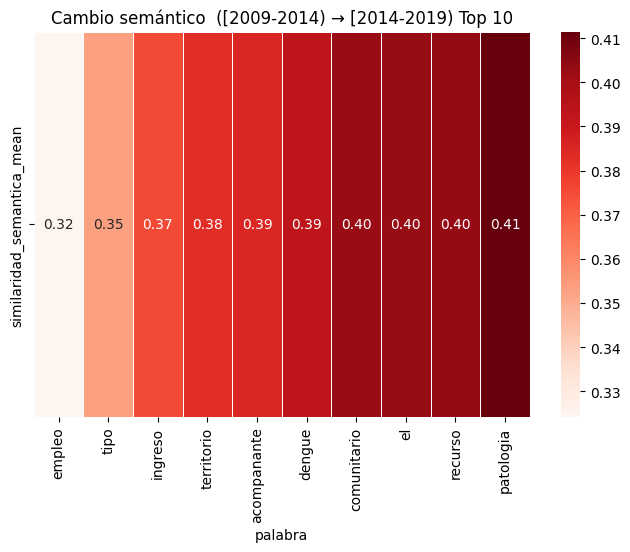

TOP 10 Palabras: ['empleo' 'tipo' 'ingreso' 'territorio' 'acompanante' 'dengue'
 'comunitario' 'el' 'recurso' 'patologia']


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10
118,"(2009, 2014)",empleo,0.324193,"(0.3157658079543117, 0.33340039425717294)","{comunitario, hogar, equivalente, nivel, familia, jefe}","{elemento, formacion, asignacion, contributivo, subsistema, ftalato, sustancia}"
324,"(2009, 2014)",tipo,0.353474,"(0.3457579396706319, 0.3610847644949076)","{avance, causado, virus, gripe, h1n1, papiloma, aparicion, influenza}","{cualquiera, mercurio, ensenanza, fabricacion}"
174,"(2009, 2014)",ingreso,0.374986,"(0.3668127609121415, 0.3828470467135649)","{anses, ganancia, fincini, ciudadano, geriatrico, ninez}","{maquina, virus, solar, categoria, ninez}"
323,"(2009, 2014)",territorio,0.382965,"(0.37243684312347564, 0.39260252943863166)","{corriente, reconocer, lavanderia, percloroetileno, tintoreria}","{natural, republica, restaurante, tecnologico}"
4,"(2009, 2014)",acompanante,0.385151,"(0.37867500185855757, 0.39201489404050754)","{nacimiento, gratuidad, parto, permanencia, embarazo, recien, proceso}","{piercing, equinoterapia, terapeutico, recurso, cosmetologia, obstetricia, cosmiatrio}"
84,"(2009, 2014)",dengue,0.393630,"(0.38788975113805113, 0.3991380240805996)","{chaco, tropical, epidemia, emergente, seguimiento, aparicion, territorio}","{virus, fiebre, comprendido}"
65,"(2009, 2014)",comunitario,0.402430,"(0.3924988968362833, 0.4114690451141395)","{direccion, sanitaria, hogar, revestir, radicacion, voluntario, militar}","{marzo, financiero, familia, accion}"
111,"(2009, 2014)",el,0.402771,"(0.3962024900010215, 0.409767874662569)","{regional, juvenil, infanto, febrero, infeccion, septiembre, identificar, rioja, hidrogenado}","{clinico, consentimiento, doctor, septiembre, premio}"
281,"(2009, 2014)",recurso,0.403233,"(0.39645288196405276, 0.41031146638253785)","{trazabilidad, superior, enfermeria, tecnologico, pandemia, tecnico, aptitud, verificacion}","{acv, acompanante, cerebrovascular, equinoterapia, terapeutico, acvo, obstetricia}"
237,"(2009, 2014)",patologia,0.411419,"(0.40385431147510736, 0.4189179418427644)","{puerperio, radiacion, nocivo, mamario, mastectomia, mamaria, producido, reconstruccion, cirugia}","{visual, recien, nacido}"


dist > 0.7 (sc <= 0.3) Cambio fuerte (usos muy distintos)


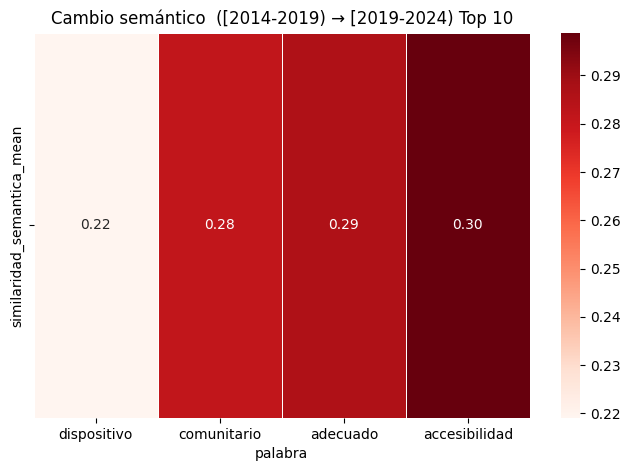

TOP 10 Palabras: ['dispositivo' 'comunitario' 'adecuado' 'accesibilidad']


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10
101,"(2014, 2019)",dispositivo,0.219099,"(0.2116572594670913, 0.2265566385301449)","{necesario, dato, similar, nocivo, electronico}","{minimo, desfibrilador, concurrencia, tecnologico, instalacion, oftalmologico, subitar}"
67,"(2014, 2019)",comunitario,0.281564,"(0.27165948468648776, 0.290427646180417)","{marzo, financiero, familia, accion}","{escolar, fortalecimiento, trabajador, reconocimiento, organizacion, presupuesto, agente, objeto}"
5,"(2014, 2019)",adecuado,0.286341,"(0.27825804628988354, 0.2936208116061226)","{rotulacion, medicinal, especialidad, camara}","{tumor, hijo, geriatrico, congreso, paliativo, manejo}"
0,"(2014, 2019)",accesibilidad,0.298858,"(0.28724259050712, 0.3092740195772763)","{consentimiento, movilidad, extension, discapacitada}","{elemento, dato, gestion, trabajo, digno}"


dist ~ 0.5 (sc ~ 0.5)  Cambio moderado


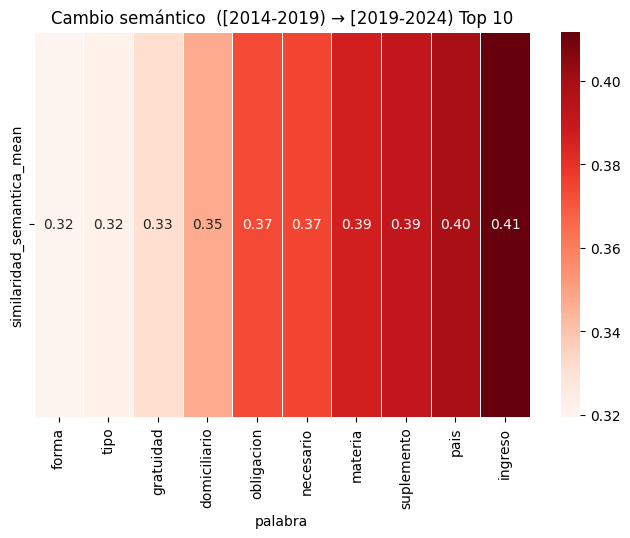

TOP 10 Palabras: ['forma' 'tipo' 'gratuidad' 'domiciliario' 'obligacion' 'necesario'
 'materia' 'suplemento' 'pais' 'ingreso']


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10
148,"(2014, 2019)",forma,0.319486,"(0.3096475531507553, 0.32785450295506097)","{complemento, cualquiera, transmision, proteina}","{domiciliario, modelo, actualizacion, organizacion, correspondiente}"
316,"(2014, 2019)",tipo,0.321460,"(0.31196973834101954, 0.33083859218558054)","{cualquiera, mercurio, ensenanza, fabricacion}","{visual, judicial, identificacion, braille, diabetes, droga}"
157,"(2014, 2019)",gratuidad,0.331567,"(0.3218824423680031, 0.34121944977961777)","{calendario, comprendido, vacuna, vacunacion}","{potable, agua, afiliado, presupuesto, pensionado}"
105,"(2014, 2019)",domiciliario,0.347000,"(0.33851897545910237, 0.35594063820341443)","{medicamento, recoleccion, inssjp, vencido}","{financiero, organizacion, educacion, forma, ter}"
231,"(2014, 2019)",obligacion,0.373731,"(0.3656400425561812, 0.38094089837290473)","{profesion, farmaceutico, afiliado, congreso, especialidad, cumplimiento}","{animal, judicial, sangre, donante, alcoholica}"
224,"(2014, 2019)",necesario,0.374349,"(0.36594618141845137, 0.38315810094567526)","{desfibrilador, concurrencia, precio, dispositivo, existir, externo, subitar}","{manejo, principio, precio}"
201,"(2014, 2019)",materia,0.386777,"(0.3779044172997835, 0.3945494875000104)","{vacunacion, politica, laboratorio, congreso, cumplimiento}","{prorrogable, sexual, chaco, vih, periodo, infeccion, adiccion}"
308,"(2014, 2019)",suplemento,0.391603,"(0.38194121911522616, 0.399852712331035)","{creatin, monohidratado, habilitado, dietario}","{libre, etiquetado, leche, fumar}"
244,"(2014, 2019)",pais,0.399096,"(0.39177295813979, 0.4064403711758043)","{deber, comercialicir, desfibrilador, acreditar}","{ambiental, clinico, desfibrilador, ciudadano, ejecutivo, instalacion, fabricacion, consejo}"
177,"(2014, 2019)",ingreso,0.411782,"(0.4046775318559608, 0.4183423182018816)","{maquina, virus, solar, categoria, ninez}","{entidad, primario, otorgar, fortalecimiento, jubilado, beneficiario, afiliado, pensionado, indice}"


In [11]:
topk = 10
for par_periodo in pares_periodo:

    print("dist > 0.7 (sc <= 0.3) Cambio fuerte (usos muy distintos)")
    periodo_df = topn_periodo[par_periodo]
    umbral_fuerte1 = 0.3
    periodo_df1 =  periodo_df[periodo_df['similaridad_semantica_mean']<=umbral_fuerte1].sort_values('similaridad_semantica_mean', ascending=True).head(topk)
    # Graficar Heatmaps
    plot_heatmap(periodo_df1[['palabra','similaridad_semantica_mean']], "Cambio semántico  (["+str(par_periodo[0])+"-"+str(par_periodo[1])+") → ["+str(par_periodo[1])+"-"+str(par_periodo[1]+5)+")", top=topk)
    print("TOP 10 Palabras:", periodo_df1['palabra'].unique())
    display(periodo_df1) 
    print("dist ~ 0.5 (sc ~ 0.5)  Cambio moderado")

    umbral_fuerte2 = 0.5
    periodo_df1 =  periodo_df[(periodo_df['similaridad_semantica_mean']<=umbral_fuerte2) & (periodo_df['similaridad_semantica_mean']>umbral_fuerte1)].sort_values('similaridad_semantica_mean', ascending=True).head(topk)
    # Graficar Heatmaps
    plot_heatmap(periodo_df1[['palabra','similaridad_semantica_mean']], "Cambio semántico  (["+str(par_periodo[0])+"-"+str(par_periodo[1])+") → ["+str(par_periodo[1])+"-"+str(par_periodo[1]+5)+")", top=topk)
    print("TOP 10 Palabras:", periodo_df1['palabra'].unique())
    display(periodo_df1)    


In [12]:
# GUARDAR OBJETO
with open(modelo_dir+'/top300_periodos_procrustes_df.pkl', 'wb') as file: 
    pickle.dump(topn_periodo,file)

Palabras comunes entre los pares de períodos

In [13]:
# palabra común en entre períodos
palabra_comun = set(topn_periodo[(2009, 2014)]['palabra'].unique()) & set(topn_periodo[(2014, 2019)]['palabra'].unique())
print("Cantidad de palabras en común:",len(palabra_comun))

Cantidad de palabras en común: 269


Top 10

In [14]:
# Período (2009, 2014)
df = topn_periodo[(2009, 2014)]
df = df[df['palabra'].isin(palabra_comun)]
df = df[['palabra','similaridad_semantica_mean','similaridad_semantica_confidence_intervals','vt1_top10','vt2_top10']]
df.columns = ['palabra','ss_mean_2009_2014','ss_ci_2009_2014','vt1_top10_2009_2014','vt2_top10_2009_2014']
# Período (2014, 2019)
df2 = topn_periodo[(2014, 2019)]
df2 = df2[df2['palabra'].isin(palabra_comun)]
df2 = df2[['palabra','similaridad_semantica_mean','similaridad_semantica_confidence_intervals','vt1_top10','vt2_top10']]
df2.columns = ['palabra','ss_mean_2014_2019','ss_ci_2014_2019','vt1_top10_2014_2019','vt2_top10_2014_2019']
# Unión
df = df.merge(df2, how='inner', on='palabra')
df = df[['palabra', 'ss_mean_2009_2014', 'ss_mean_2014_2019', 'ss_ci_2009_2014','ss_ci_2014_2019','vt1_top10_2009_2014','vt2_top10_2009_2014', 'vt1_top10_2014_2019','vt2_top10_2014_2019']]
df['peso'] = (df['ss_mean_2009_2014'] + df['ss_mean_2014_2019'] )/2
print("Top 10 de palabras comunes con Fuerte cambio semántco entre Período [2009, 2014) - > [2014, 2019)  ")
print("Palabras:",df[df['peso']<=0.3].sort_values('peso').head(10)['palabra'].unique() )
display(df[df['peso']<=0.3].sort_values('peso').head(10))
print("Top 10 de palabras comunes con moderado cambio semántco entre Período [2009, 2014) - > [2014, 2019)  ")
print("Palabras:",df[(df['peso']>0.3) & (df['peso']<=0.5)].sort_values('peso').head(10)['palabra'].unique() )
display(df[(df['peso']>0.3) & (df['peso']<=0.5)].sort_values('peso').head(10))



Top 10 de palabras comunes con Fuerte cambio semántco entre Período [2009, 2014) - > [2014, 2019)  
Palabras: []


,palabra,ss_mean_2009_2014,ss_mean_2014_2019,ss_ci_2009_2014,ss_ci_2014_2019,vt1_top10_2009_2014,vt2_top10_2009_2014,vt1_top10_2014_2019,vt2_top10_2014_2019,peso


Top 10 de palabras comunes con moderado cambio semántco entre Período [2009, 2014) - > [2014, 2019)  
Palabras: ['materia' 'tipo' 'comunitario' 'legal' 'ingreso' 'gratuidad'
 'domiciliario' 'necesario' 'argentina' 'obligacion']


,palabra,ss_mean_2009_2014,ss_mean_2014_2019,ss_ci_2009_2014,ss_ci_2014_2019,vt1_top10_2009_2014,vt2_top10_2009_2014,vt1_top10_2014_2019,vt2_top10_2014_2019,peso
163,materia,0.284821,0.386777,"(0.27599544304365015, 0.2939124981934813)","(0.3779044172997835, 0.3945494875000104)","{estr, postraumatico, basica, fortalecimiento, presupuesto, delito, adopcion, primaria}","{vacunacion, politica, laboratorio, congreso, cumplimiento}","{vacunacion, politica, laboratorio, congreso, cumplimiento}","{prorrogable, sexual, chaco, vih, periodo, infeccion, adiccion}",0.335799
254,tipo,0.353474,0.321460,"(0.3457579396706319, 0.3610847644949076)","(0.31196973834101954, 0.33083859218558054)","{avance, causado, virus, gripe, h1n1, papiloma, aparicion, influenza}","{cualquiera, mercurio, ensenanza, fabricacion}","{cualquiera, mercurio, ensenanza, fabricacion}","{visual, judicial, identificacion, braille, diabetes, droga}",0.337467
53,comunitario,0.402430,0.281564,"(0.3924988968362833, 0.4114690451141395)","(0.27165948468648776, 0.290427646180417)","{direccion, sanitaria, hogar, revestir, radicacion, voluntario, militar}","{marzo, financiero, familia, accion}","{marzo, financiero, familia, accion}","{escolar, fortalecimiento, trabajador, reconocimiento, organizacion, presupuesto, agente, objeto}",0.341997
153,legal,0.226934,0.543984,"(0.22002384660263957, 0.23402394056119352)","(0.5352329596648002, 0.5522952713932889)","{norma, loteria, colaborador, odontologia, auxiliar, musicoterapia}","{embarazo, monodroga, misoprostol, droga}","{embarazo, monodroga, misoprostol, droga}","{ingreso, obstetricia, beneficiario, misoprostol}",0.385459
144,ingreso,0.374986,0.411782,"(0.3668127609121415, 0.3828470467135649)","(0.4046775318559608, 0.4183423182018816)","{anses, ganancia, fincini, ciudadano, geriatrico, ninez}","{maquina, virus, solar, categoria, ninez}","{maquina, virus, solar, categoria, ninez}","{entidad, primario, otorgar, fortalecimiento, jubilado, beneficiario, afiliado, pensionado, indice}",0.393384
126,gratuidad,0.530001,0.331567,"(0.5215224657247469, 0.5362155310817255)","(0.3218824423680031, 0.34121944977961777)","{acompanante, indirecto, permanencia, directo, rotavirus, prohibir, proceso}","{calendario, comprendido, vacuna, vacunacion}","{calendario, comprendido, vacuna, vacunacion}","{potable, agua, afiliado, presupuesto, pensionado}",0.430784
84,domiciliario,0.524213,0.347000,"(0.5168327490635526, 0.5313936901079658)","(0.33851897545910237, 0.35594063820341443)","{recoleccion, mercurio, odontologico, instrumento, capacidad, civil, vencido, partos}","{medicamento, recoleccion, inssjp, vencido}","{medicamento, recoleccion, inssjp, vencido}","{financiero, organizacion, educacion, forma, ter}",0.435606
180,necesario,0.514073,0.374349,"(0.5046100003397483, 0.5234496252933362)","(0.36594618141845137, 0.38315810094567526)","{olivia, ostomizada, incluyendolo, presupuesto, medicacion}","{desfibrilador, concurrencia, precio, dispositivo, existir, externo, subitar}","{desfibrilador, concurrencia, precio, dispositivo, existir, externo, subitar}","{manejo, principio, precio}",0.444211
23,argentina,0.449219,0.444398,"(0.4412629631395372, 0.4568344693132116)","(0.4343261884368739, 0.4541177447759303)","{prioritario, limitacion, chagas, bioetica, cigarrillo, riesgo, republica, comercializado, tabaco}","{erupcion, comision, tecnologico, natural, republica}","{erupcion, comision, tecnologico, natural, republica}","{tecnologia, evaluacion, desfibrilador, exigencia, pobreza, prevenibl, republica}",0.446809
186,obligacion,0.521945,0.373731,"(0.511019733045155, 0.5328740465464675)","(0.3656400425561812, 0.38094089837290473)","{willi, omision, existir, posibilidad, prader, spw, cromosomatico}","{profesion, farmaceutico, afiliado, congreso, especialidad, cumplimiento}","{profesion, farmaceutico, afiliado, congreso, especialidad, cumplimiento}","{animal, judicial, sangre, donante, alcoholica}",0.447838


In [15]:
# GUARDAR OBJETO
with open(modelo_dir+'/palComun_cambioSem_procrustes_df.pkl', 'wb') as file: 
    pickle.dump(df,file)

In [16]:
# Palabras en común
df.palabra.unique()

array(['accesibilidad', 'acceso', 'accidente', 'acompanante', 'actividad',
       'adiccion', 'administracion', 'adolescente', 'afectado', 'agente',
       'agua', 'aires', 'alimentacion', 'alimentario', 'alimenticio',
       'alimento', 'alto', 'animal', 'ano', 'anos', 'anual', 'aplicacion',
       'apto', 'argentina', 'argentino', 'articulo', 'asignacion',
       'asistencia', 'asistencial', 'atencion', 'autonoma', 'banco',
       'basica', 'bebida', 'beneficiario', 'beneficio', 'calendario',
       'calidad', 'campana', 'cancer', 'capacitacion', 'caracter',
       'celiaca', 'celiaco', 'centro', 'certificado', 'ciudad',
       'ciudadano', 'codigo', 'comercializacion', 'comida', 'complejidad',
       'complementario', 'comunitario', 'concientizacion', 'condicion',
       'consecuencia', 'consentimiento', 'consumidor', 'consumo',
       'control', 'cronico', 'cualquiera', 'cuidado', 'cuyo', 'decreto',
       'demas', 'dengue', 'denominado', 'dependencia', 'deportivo',
       'derecho

Buscando palabras asociadas a "muerte súbita"

In [17]:
ms_lista = ['desfibrilador','cardiopulmonar','cardioasistido','cardio','subitar','subita','dea','dispositivo', 'emergencia','supervivencia','reanimacion','prevencion']
for palabra in ms_lista:
    for par_periodo in pares_periodo:
        
        df = topn_periodo[par_periodo]
        busqueda = df[df['palabra'].str.contains(palabra)]
        if (len(busqueda)>0):
            print(par_periodo)
            display(busqueda)

(2014, 2019)


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10
101,"(2014, 2019)",dispositivo,0.219099,"(0.2116572594670913, 0.2265566385301449)","{necesario, dato, similar, nocivo, electronico}","{minimo, desfibrilador, concurrencia, tecnologico, instalacion, oftalmologico, subitar}"


(2009, 2014)


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10
117,"(2009, 2014)",emergencia,0.704497,"(0.695627929562879, 0.711524332928565)","{medioambiental, prorrogable, chaco, zona}","{termino, prorrogable, cordoba, medioambiental, agropecuario, productivo}"


(2014, 2019)


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10
120,"(2014, 2019)",emergencia,0.728426,"(0.7200668120531111, 0.7351552202955262)","{termino, prorrogable, cordoba, medioambiental, agropecuario, productivo}","{prorrogable, departamento, zona, chaco, sanitario, desastre}"


(2009, 2014)


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10
257,"(2009, 2014)",prevencion,0.737291,"(0.7353887799999999, 0.7393838199999999)","{transmisibl, cerebrovascular, acvo, seguimiento, delito}","{accidente, acv, exposicion, cerebrovascular, acvo, dengue, comite, fiebre}"


### Visualizaciones

t-SNE (t-distributed Stochastic Neighbor Embedding) es un algoritmo de reducción de dimensionalidad que:

Preserva las relaciones locales entre los vectores (es decir, quién está cerca de quién).

No preserva distancias globales ni direcciones.


In [18]:
## 2. Visualización del desplazamiento con t-SNE

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE


def compute_cosine_similarity(model1,model2,word):
    vector1 = model1.wv[word].reshape(1,-1)
    vector2 = model2.wv[word].reshape(1,-1)
    return(cosine_similarity(X=vector1, Y=vector2)[0][0])

def reducir_dimensionalidad( embeddings, n_components=2, perplexity=5, palabrasComun = []):
    if len(palabrasComun)>0:
        words = palabrasComun
    else:
        words = list(embeddings.keys())
    
    vectors = np.array([embeddings.wv.get_vector(word)  for word in words])
    #embeddings[word]  
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=42)
    reduced_vectors = tsne.fit_transform(vectors)
    
    return reduced_vectors


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Función para reducir dimensiones con t-SNE
def reducir_dimensionalidad(embeddings, n_components=2, perplexity=5):
    words = list(embeddings.keys())
    vectors = np.array([embeddings[word] for word in words])
    
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=42)
    reduced_vectors = tsne.fit_transform(vectors)
    
    return words, reduced_vectors

def reducir_dimensionalidad( embeddings, n_components=2, perplexity=5, palabrasComun = []):
    if len(palabrasComun)>0:
        words = palabrasComun
    else:
        words = list(embeddings.keys())
    
    vectors = np.array([embeddings.wv.get_vector(word)  for word in words])
    #embeddings[word]  
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=42)
    reduced_vectors = tsne.fit_transform(vectors)
    
    return reduced_vectors


# Función para visualizar cambio semántico
def plot_word_shifts(words, m1, m2, vecs1, vecs2, pares, title="Cambio semántico"):
    plt.figure(figsize=(15, 10),tight_layout=True)
    
    for i, word in enumerate(words):
        dist = 1 - compute_cosine_similarity(m1,m2,word)

        plt.scatter(vecs1[i, 0], vecs1[i, 1], color='blue', alpha=0.6)
        plt.scatter(vecs2[i, 0], vecs2[i, 1], color='red', alpha=0.6)
        plt.plot([vecs1[i, 0], vecs2[i, 0]], [vecs1[i, 1], vecs2[i, 1]], color='gray', alpha=0.5)
        plt.text(vecs2[i, 0], vecs2[i, 1], f"{word}\n∆={dist:.2f}", fontsize=9,color='black',ha="left")
        

    
    plt.xlabel("t-SNE Dim 1")
    plt.ylabel("t-SNE Dim 2")
    plt.title(title,fontsize=20)
    plt.legend([pares[0], pares[1],"Desplazamiento 1−similitud coseno"])
    #plt.tight_layout()
    #plt.subplots_adjust(left=0.2, right=0.5)

    plt.show()

In [20]:
def compute_cosine_similarity(model1,model2,word):
    vector1 = model1.wv[word].reshape(1,-1)
    vector2 = model2.wv[word].reshape(1,-1)
    return(cosine_similarity(X=vector1, Y=vector2)[0][0])

In [21]:
# Crear directorio para algoritmo de cambio semántico
# Crear directorio modelo alineado
alin_dir = modelo_dir +'/estabilidad_procrustes/alineado/'
iter = 0

In [22]:
# modelos alineados por procuster para iter 0
m_2009 = Word2Vec.load(alin_dir+"alin_" + str(2009)+'_'+str(iter)+'.mdl')
m_2014 = Word2Vec.load(alin_dir+"alin_" + str(2014)+'_'+str(iter)+'.mdl') 
m_2019 = Word2Vec.load(alin_dir+"alin_" + str(2019)+'_'+str(iter)+'.mdl')   

In [23]:
# Inicializar estructura de vectores por palabra
from collections import defaultdict
vectores_por_palabra = {}
vectores_promedio = {}

def get_vector_modelo(vectores,periodo,i):
    modelo = Word2Vec.load(alin_dir+"alin_" + str(2009)+'_'+str(i)+'.mdl')
    for palabra in modelo.wv.key_to_index:
        vectores[palabra].append(modelo.wv[palabra])
    return vectores
    
for periodo in [2009,2014,2019]:
    # Por período
    vectores_por_palabra[periodo] = defaultdict(list)
    for i in range(50):
        vectores_por_palabra[periodo] = get_vector_modelo(vectores_por_palabra[periodo],periodo,i)
    #Calcular vector medio solo para palabras con presencia en todas las iteraciones (opcional)
    vectores_promedio[periodo] = {pal: np.mean(vs, axis=0) for pal, vs in vectores_por_palabra[periodo].items() if len(vs) == 50}

In [24]:
vectores_promedio[2009]['legal'] # valor medio para 50 iteraciones

array([ 0.03386116,  0.01979908,  0.0235684 , -0.03931092, -0.05077127,
       -0.00764325, -0.02402897,  0.0280278 ,  0.03654732, -0.00992181,
       -0.02017468, -0.00902563, -0.02601072,  0.07172029, -0.03031558,
       -0.06429392, -0.03264044, -0.0146622 ,  0.05480341,  0.0027044 ,
       -0.07296082, -0.01335669, -0.00749999,  0.00302   , -0.0602397 ,
       -0.03526606, -0.02929291,  0.00401702, -0.06919349, -0.04099877,
       -0.01134325,  0.0061632 ,  0.06062879,  0.00537883,  0.02226957,
        0.08309307, -0.06272247, -0.02129675, -0.04272402,  0.05645285,
        0.02230948, -0.02455899,  0.0655199 ,  0.14147106,  0.04031063,
        0.0272153 ,  0.04139757, -0.05539588, -0.03975792, -0.01716769,
       -0.03006174, -0.09663133, -0.00344653, -0.02055298, -0.04369729,
       -0.07876275,  0.04468465, -0.07359283,  0.03923837,  0.01410503,
        0.02767386,  0.05716614,  0.03775274,  0.0223511 , -0.00542594,
        0.00067086,  0.10203955,  0.0234501 , -0.00144961,  0.05

In [25]:
# Cambios moderados
palabrasmc_2009_2014 = ['legal', 'declaracion', 'materia','empleo', 'tipo' ,'ingreso', 'territorio' ,'acompanante' ,'dengue' , 'comunitario' ,'recurso' ,'patologia']

# Reducir dimensiones para los períodos alineados
#vecs_1 = reducir_dimensionalidad(m_2009, palabrasComun = palabrasmc_2009_2014 ) 
#vecs_2 = reducir_dimensionalidad(m_2014, palabrasComun = palabrasmc_2009_2014 )
# Graficar cambios semánticos en palabras clave
#titulo = "Desplazamiento semántico con t-SNE"
#plot_word_shifts(palabrasmc_2009_2014,m_2009,m_2014, vecs_1, vecs_2, ('2009-2014','2014-2019'),titulo)
#No interpretar literalmente las distancias o direcciones en t-SNE (porque puede reordenar todo en 2D).

#    Azul: Ubicación de la palabra en el primer período.
#    Rojo: Ubicación en el segundo período.
#    Línea gris: Movimiento del significado de la palabra.




##### iteración 0

In [26]:
periodo_df = topn_periodo_all[(2009,2014)]
periodo_df = periodo_df[periodo_df.iteracion==0]
periodo_df = periodo_df[periodo_df['palabra'].isin(palabrasmc_2009_2014)][['palabra','similaridad_semantica','top10_vecindad_t1','top10_vecindad_t2']]
periodo_df['vt1'] = periodo_df['top10_vecindad_t1'].apply(lambda x: [ peso[0] for peso in eval(x) ])
periodo_df['vt2'] = periodo_df['top10_vecindad_t2'].apply(lambda x: [ peso[0] for peso in eval(x) ])
periodo_df[['palabra','similaridad_semantica','vt1','vt2']]


,palabra,similaridad_semantica,vt1,vt2
0,materia,0.244783,"[adopcion, basica, primaria, presupuesto, estr, postraumatico, delito, fortalecimiento, objetivo, prostata]","[congreso, cumplimiento, vacunacion, laboratorio, politica, produccion, economico, muerte, consentimiento, voluntario]"
1,legal,0.262212,"[auxiliar, loteria, odontologia, norma, colaborador, obstetricia, ejercicio, musicoterapia, capitulo, fitoterapicos]","[droga, monodroga, tipo, misoprostol, terapia, planta, fitoterapicos, vegetal, embarazo, laser]"
2,declaracion,0.272819,"[jujuy, valle, rioja, accion, natural, departamento, chaco, vital, epidemiologico, mendoza]","[prepagar, valor, suspension, marco, medicina, comision, maternidad, listado, transcurso, lectivo]"
3,ingreso,0.304698,"[ninez, fincini, ciudadano, anses, ganancia, basico, geriatrico, diabetes, ordenado, fisico]","[categoria, solar, ninez, maquina, virus, ciudadano, fiebre, explotacion, federal, politica]"
4,tipo,0.346922,"[aparicion, causado, h1n1, papiloma, gripe, influenza, avance, virus, hpv, neumococo]","[ensenanza, cualquiera, fabricacion, medicamentosa, instrumento, organo, droga, mercurio, importacion, deportivo]"
5,empleo,0.359739,"[hogar, jefe, familia, equivalente, comunitario, monto, contencion, nivel, observatorio, remuneracion]","[ftalato, elemento, contributivo, subsistema, sustancia, asignacion, formacion, monodroga, alergena, mercurio]"
7,recurso,0.379445,"[tecnologico, tecnico, enfermeria, trazabilidad, verificacion, aptitud, superior, pandemia, gripe, periodico]","[terapeutico, acompanante, acvo, cerebrovascular, equinoterapia, acv, promover, obstetricia, artriti, tatuaj]"
8,acompanante,0.387432,"[permanencia, proceso, parto, gratuidad, nacimiento, embarazo, recien, mujer, puerperio, consultoria]","[obstetricia, terapeutico, cosmetologia, cosmiatrio, equinoterapia, recurso, piercing, tatuaj, perforacion, tecnico]"
11,comunitario,0.398697,"[militar, sanitaria, revestir, radicacion, direccion, voluntario, hogar, adiccion, monto, observatorio]","[accion, financiero, familia, marzo, julio, prestacion, enero, maternidad, desarrollo, enfermo]"
12,dengue,0.406011,"[epidemia, emergente, tropical, chaco, territorio, seguimiento, aparicion, ochenta, prioritario, demencia]","[fiebre, comprendido, virus, tumor, nosocomial, intrahospitalaria, paliativo, digno, alzheimer, lectivo]"


In [27]:
for palabra in palabrasmc_2009_2014:
    for par_periodo in pares_periodo:
        
        df = topn_periodo[par_periodo]
        busqueda = df[df['palabra'].str.contains(palabra)]
        if (len(busqueda)>0):
            print(par_periodo)
            display(busqueda)

(2009, 2014)


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10
185,"(2009, 2014)",legal,0.226934,"(0.22002384660263957, 0.23402394056119352)","{norma, loteria, colaborador, odontologia, auxiliar, musicoterapia}","{embarazo, monodroga, misoprostol, droga}"


(2014, 2019)


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10
190,"(2014, 2019)",legal,0.543984,"(0.5352329596648002, 0.5522952713932889)","{embarazo, monodroga, misoprostol, droga}","{ingreso, obstetricia, beneficiario, misoprostol}"


(2009, 2014)


...

,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10
281,"(2009, 2014)",recurso,0.403233,"(0.39645288196405276, 0.41031146638253785)","{trazabilidad, superior, enfermeria, tecnologico, pandemia, tecnico, aptitud, verificacion}","{acv, acompanante, cerebrovascular, equinoterapia, terapeutico, acvo, obstetricia}"


(2009, 2014)


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10
237,"(2009, 2014)",patologia,0.411419,"(0.40385431147510736, 0.4189179418427644)","{puerperio, radiacion, nocivo, mamario, mastectomia, mamaria, producido, reconstruccion, cirugia}","{visual, recien, nacido}"


(2014, 2019)


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10
246,"(2014, 2019)",patologia,0.588259,"(0.5802665037854571, 0.5953532777360178)","{visual, recien, nacido}","{equinoterapia, estetico, mama, cirugia}"


In [28]:
palabrasmc_2014_2019 = ['dispositivo' ,'comunitario' ,'adecuado' ,'accesibilidad','forma', 'tipo', 'gratuidad' ,'domiciliario' ,'obligacion' ,'necesario',
 'materia' ,'suplemento' ,'pais' ,'ingreso']
# Reducir dimensiones para los períodos alineados
# vecs_1 = reducir_dimensionalidad(m_2014, palabrasComun = palabrasmc_2014_2019 ) 
# vecs_2 = reducir_dimensionalidad(m_2019, palabrasComun = palabrasmc_2014_2019 )
# titulo = "Desplazamiento semántico con t-SNE"
# plot_word_shifts(palabrasmc_2014_2019,m_2014,m_2019, vecs_1, vecs_2, ('2014-2019','2019-2024'),titulo)  


In [29]:
periodo_df = topn_periodo_all[(2014,2019)]
periodo_df = periodo_df[periodo_df.iteracion==0]
periodo_df = periodo_df[periodo_df['palabra'].isin(palabrasmc_2014_2019)][['palabra','similaridad_semantica','top10_vecindad_t1','top10_vecindad_t2']]
periodo_df['vt1'] = periodo_df['top10_vecindad_t1'].apply(lambda x: [ peso[0] for peso in eval(x) ])
periodo_df['vt2'] = periodo_df['top10_vecindad_t2'].apply(lambda x: [ peso[0] for peso in eval(x) ])
periodo_df[['palabra','similaridad_semantica','vt1','vt2']]

,palabra,similaridad_semantica,vt1,vt2
0,dispositivo,0.204944,"[nocivo, electronico, similar, dato, digital, necesario, efecto, transgenico, receta, leches]","[tecnologico, minimo, subitar, concurrencia, desfibrilador, oftalmologico, examen, instalacion, aplicacion, comprendido]"
1,accesibilidad,0.214502,"[movilidad, discapacitada, consentimiento, extension, multiple, informado, trasplantado, permanente, equinoterapia, poblacion]","[trabajo, dato, digno, elemento, gestion, etiqueta, fumar, ame, muscular, espinal]"
2,comunitario,0.296773,"[accion, financiero, familia, marzo, julio, prestacion, enero, maternidad, desarrollo, enfermo]","[presupuesto, escolar, agente, organizacion, objeto, reconocimiento, fortalecimiento, trabajador, tumor, grasa]"
3,adecuado,0.300632,"[rotulacion, camara, especialidad, medicinal, capitulo, gasificado, alimentario, jugo, porcentaje, alcohol]","[geriatrico, tumor, manejo, paliativo, congreso, modificatoria, agente, diabetes, hijo, situacion]"
4,tipo,0.308893,"[ensenanza, cualquiera, fabricacion, medicamentosa, instrumento, organo, droga, mercurio, importacion, deportivo]","[droga, judicial, visual, diabetes, braille, animal, identificacion, pensionado, secundario, tecnica]"
5,domiciliario,0.311896,"[vencido, recoleccion, medicamento, inssjp, resolucion, pami, tecnologia, planta, vegetal, pensionado]","[financiero, forma, educacion, organizacion, trasplantado, ter, cualquiera, fisico, actividad, trabajo]"
6,forma,0.325743,"[transmision, complemento, proteina, adiccion, cualquiera, examen, apto, biomedico, gratuito, tecnica]","[actualizacion, domiciliario, organizacion, correspondiente, modelo, modificatoria, hijo, respectivamente, mundial, ter]"
7,materia,0.350868,"[congreso, cumplimiento, vacunacion, laboratorio, politica, produccion, economico, muerte, consentimiento, voluntario]","[vih, prorrogable, infeccion, periodo, sexual, adiccion, chaco, plazo, zona, abril]"
8,pais,0.362645,"[comercialicir, deber, acreditar, desfibrilador, externo, punto, sexo, autoridad, envase, geriatrico]","[ejecutivo, fabricacion, instalacion, ciudadano, desfibrilador, ambiental, clinico, laboratorio, recoleccion, consejo]"
9,gratuidad,0.371379,"[calendario, vacunacion, vacuna, infanto, juvenil, comprendido, paciente, administracion, otorgar, area]","[potable, agua, pensionado, presupuesto, jubilado, ter, trabajador, afiliado, afectado, dependencia]"


In [30]:
for palabra in palabrasmc_2014_2019:
    for par_periodo in pares_periodo:
        
        df = topn_periodo[par_periodo]
        busqueda = df[df['palabra'].str.contains(palabra)]
        if (len(busqueda)>0):
            print(par_periodo)
            display(busqueda)

(2014, 2019)


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10
101,"(2014, 2019)",dispositivo,0.219099,"(0.2116572594670913, 0.2265566385301449)","{necesario, dato, similar, nocivo, electronico}","{minimo, desfibrilador, concurrencia, tecnologico, instalacion, oftalmologico, subitar}"


(2009, 2014)


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10
65,"(2009, 2014)",comunitario,0.40243,"(0.3924988968362833, 0.4114690451141395)","{direccion, sanitaria, hogar, revestir, radicacion, voluntario, militar}","{marzo, financiero, familia, accion}"


(2014, 2019)


...

,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10
244,"(2014, 2019)",pais,0.399096,"(0.39177295813979, 0.4064403711758043)","{deber, comercialicir, desfibrilador, acreditar}","{ambiental, clinico, desfibrilador, ciudadano, ejecutivo, instalacion, fabricacion, consejo}"


(2009, 2014)


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10
174,"(2009, 2014)",ingreso,0.374986,"(0.3668127609121415, 0.3828470467135649)","{anses, ganancia, fincini, ciudadano, geriatrico, ninez}","{maquina, virus, solar, categoria, ninez}"


(2014, 2019)


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10
177,"(2014, 2019)",ingreso,0.411782,"(0.4046775318559608, 0.4183423182018816)","{maquina, virus, solar, categoria, ninez}","{entidad, primario, otorgar, fortalecimiento, jubilado, beneficiario, afiliado, pensionado, indice}"


#### Vecindades

In [31]:
## 3. Visualización de vecindades semánticas

def plot_neighbors_tsne(word, embeddings_by_period, alineados,periods, top_k=10):
    all_vectors = []
    all_labels = []
    all_colors = []
    center_coords = {}
    legend_labels = []

    color_map = plt.cm.get_cmap("tab10", len(periods))

    for i, period in enumerate(periods):
        if word not in embeddings_by_period[period]:
            print(f" '{word}' no está en el vocabulario del período {period}")
            continue
        
        center_vec = embeddings_by_period[period][word]
        vocab = embeddings_by_period[period]

   

        palabras_masSim = alineados[period].wv.most_similar(positive=[word], topn=top_k)
        neighbors = [ pal_peso[0] for pal_peso in palabras_masSim]
        #palabras_masSim_period1 = m2.wv.most_similar(positive=[palabra], topn=top_k)
        #neighbors = sorted(sims.items(), key=lambda x: x[1], reverse=True)[:top_k]

        # Agregar el centro y sus vecinos
        all_vectors.append(center_vec)
        all_labels.append(word)  # No mostrar periodo en texto
        all_colors.append(i)
        legend_labels.append((period, period+5))

        for neighbor in neighbors:
            all_vectors.append(vocab[neighbor])
            all_labels.append(neighbor)  # Solo mostrar nombre del vecino
            all_colors.append(i)
            legend_labels.append((period, period+5))

    if not all_vectors:
        print("No hay datos suficientes para graficar.")
        return

    X = np.array(all_vectors)
    tsne = TSNE(n_components=2, perplexity=5
                , random_state=42)
    X_2d = tsne.fit_transform(X)

    plt.figure(figsize=(15, 10))
    scatter_handles = {}
    idx = 0
    for i, period in enumerate(periods):
        if (period, period+5) not in legend_labels:
            continue
        color = color_map(i)
        etiqueta = "["+str(period)+","+str(period+5)+")"
        handle = plt.scatter([], [], color=color, label=etiqueta)
        scatter_handles[period] = handle

    max_dist = -1
    max_pair = None

    for i, (x, label) in enumerate(zip(X_2d, all_labels)):
        color = color_map(all_colors[i])
        period = legend_labels[i]
        plt.scatter(x[0], x[1], color=color, s=60)
        if label != word:
            plt.text(x[0], x[1], label, fontsize=9)
        else:
            # es el centro, guardar la coordenada
            plt.text(x[0], x[1], label, fontsize=10, color='blue')

   
    plt.title("Vecindades semánticas (top "+str(top_k)+") para "+word)
   
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(modelo_dir+'/estabilidad_procrustes/estabilidad_procrustes_'+word)

    plt.show()



In [32]:
# Para graficar
embeddings_by_period = {}
alineados = {}
base = 2009
vocab = {}
for modelo in [m_2009,m_2014,m_2019]:
    for word in modelo.wv.key_to_index:
        vocab[word] = modelo.wv.get_vector(word)
    embeddings_by_period[base]=  vocab
    alineados[base] = modelo
    base = base + 5


##### Iteración 0

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7648\3491657529.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", len(periods))


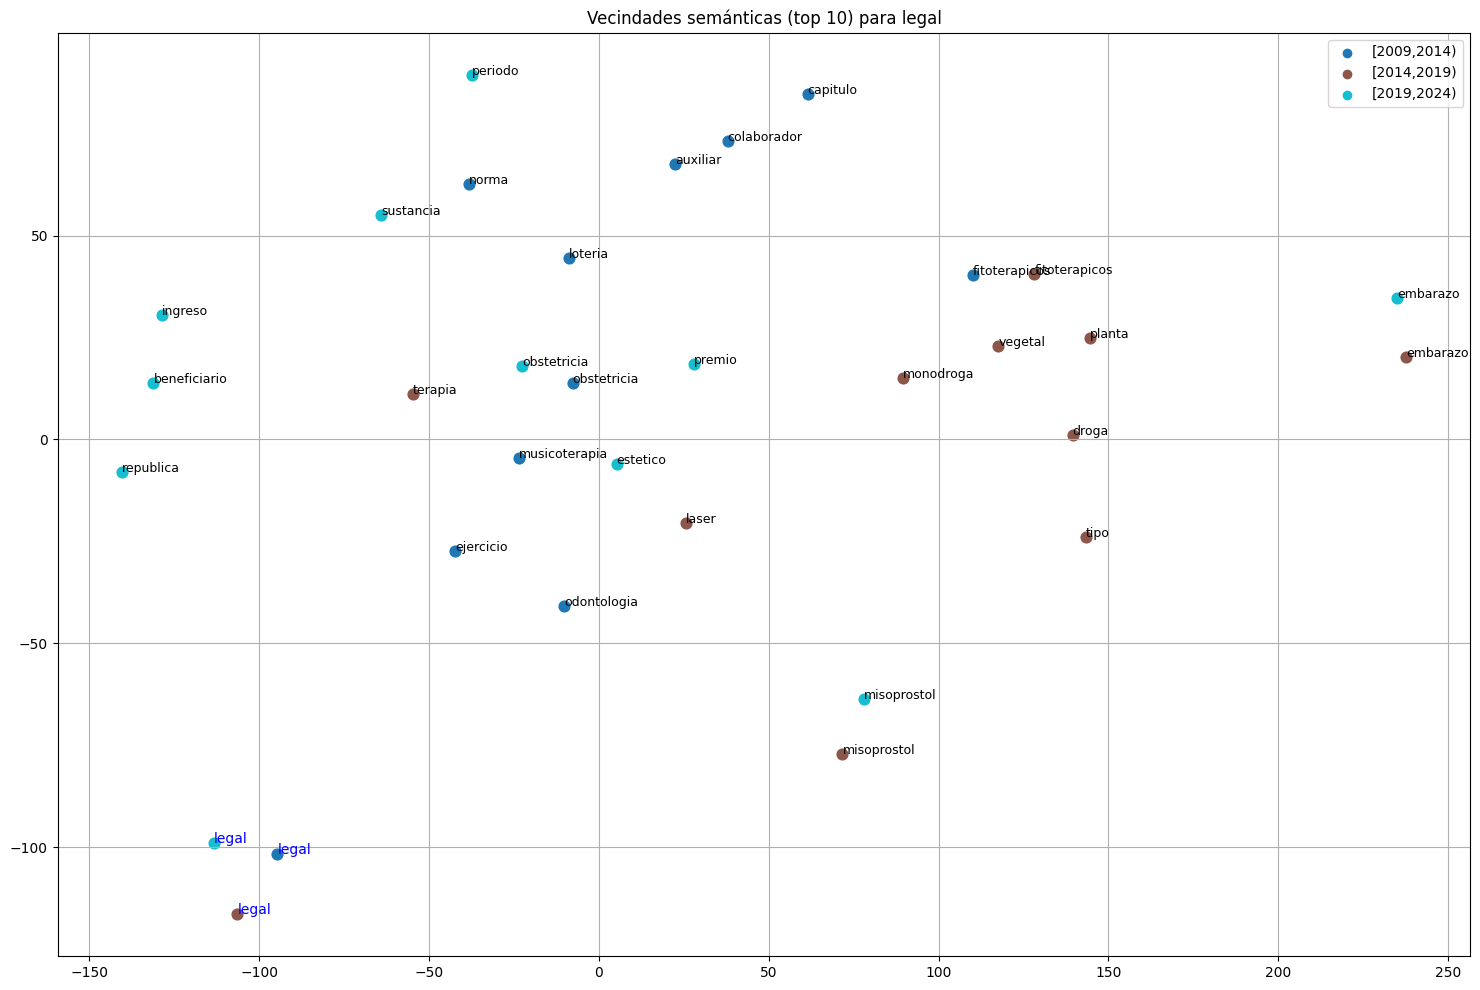

In [33]:

plot_neighbors_tsne('legal', embeddings_by_period,alineados, [2009,2014,2019], top_k=10)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_7648\3491657529.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", len(periods))


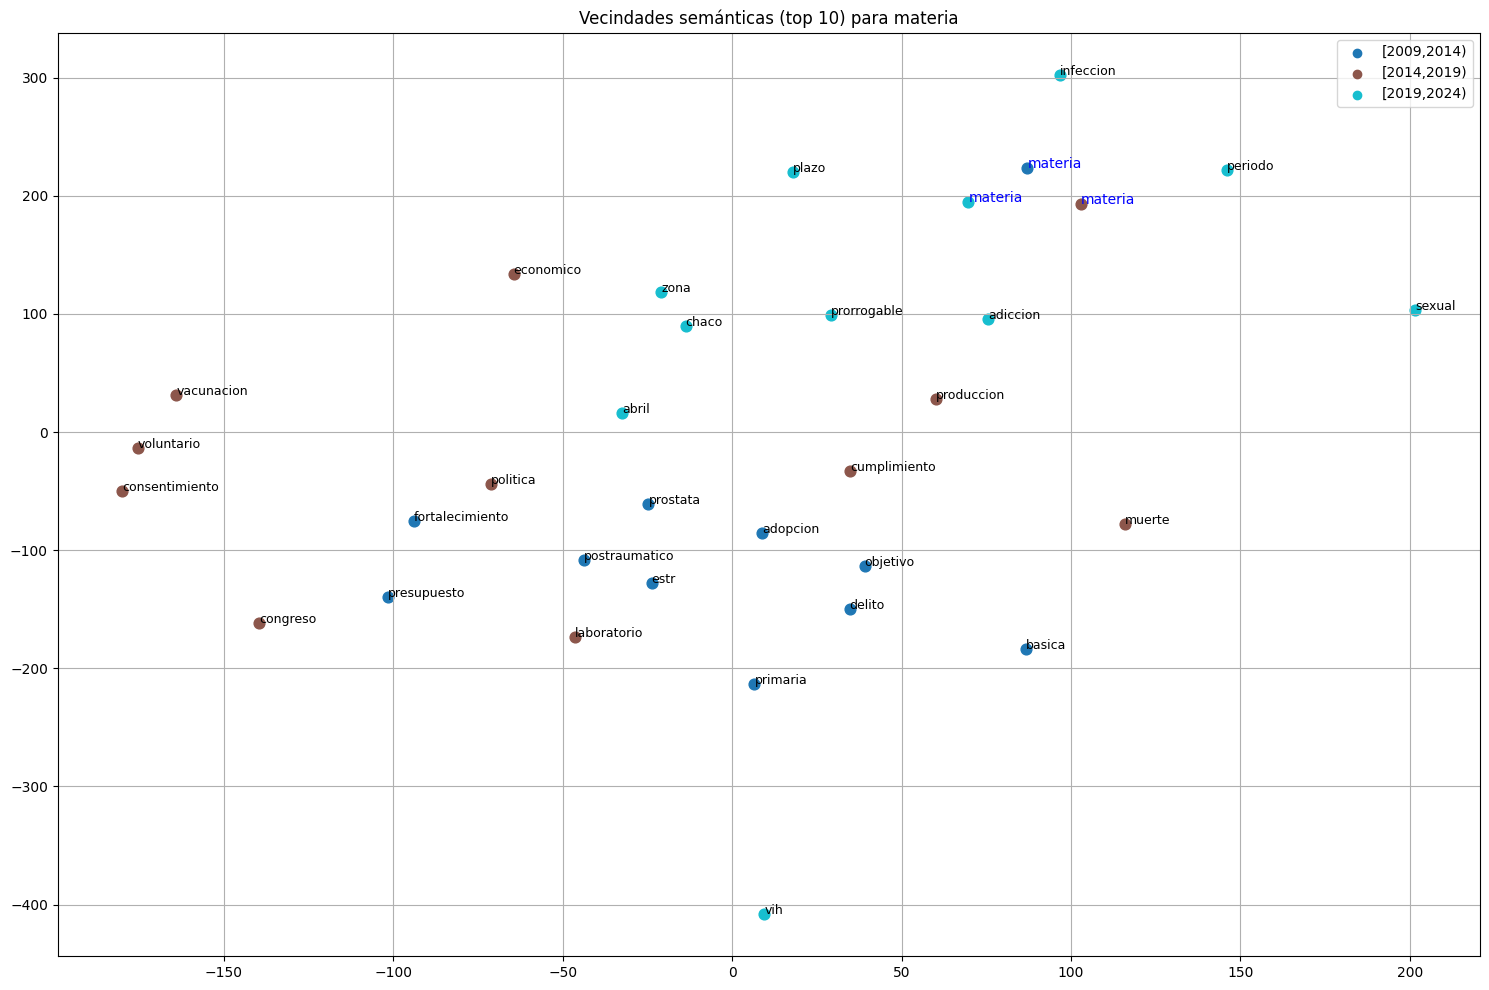

In [34]:
plot_neighbors_tsne('materia', embeddings_by_period,alineados, [2009,2014,2019], top_k=10)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_7648\3491657529.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", len(periods))


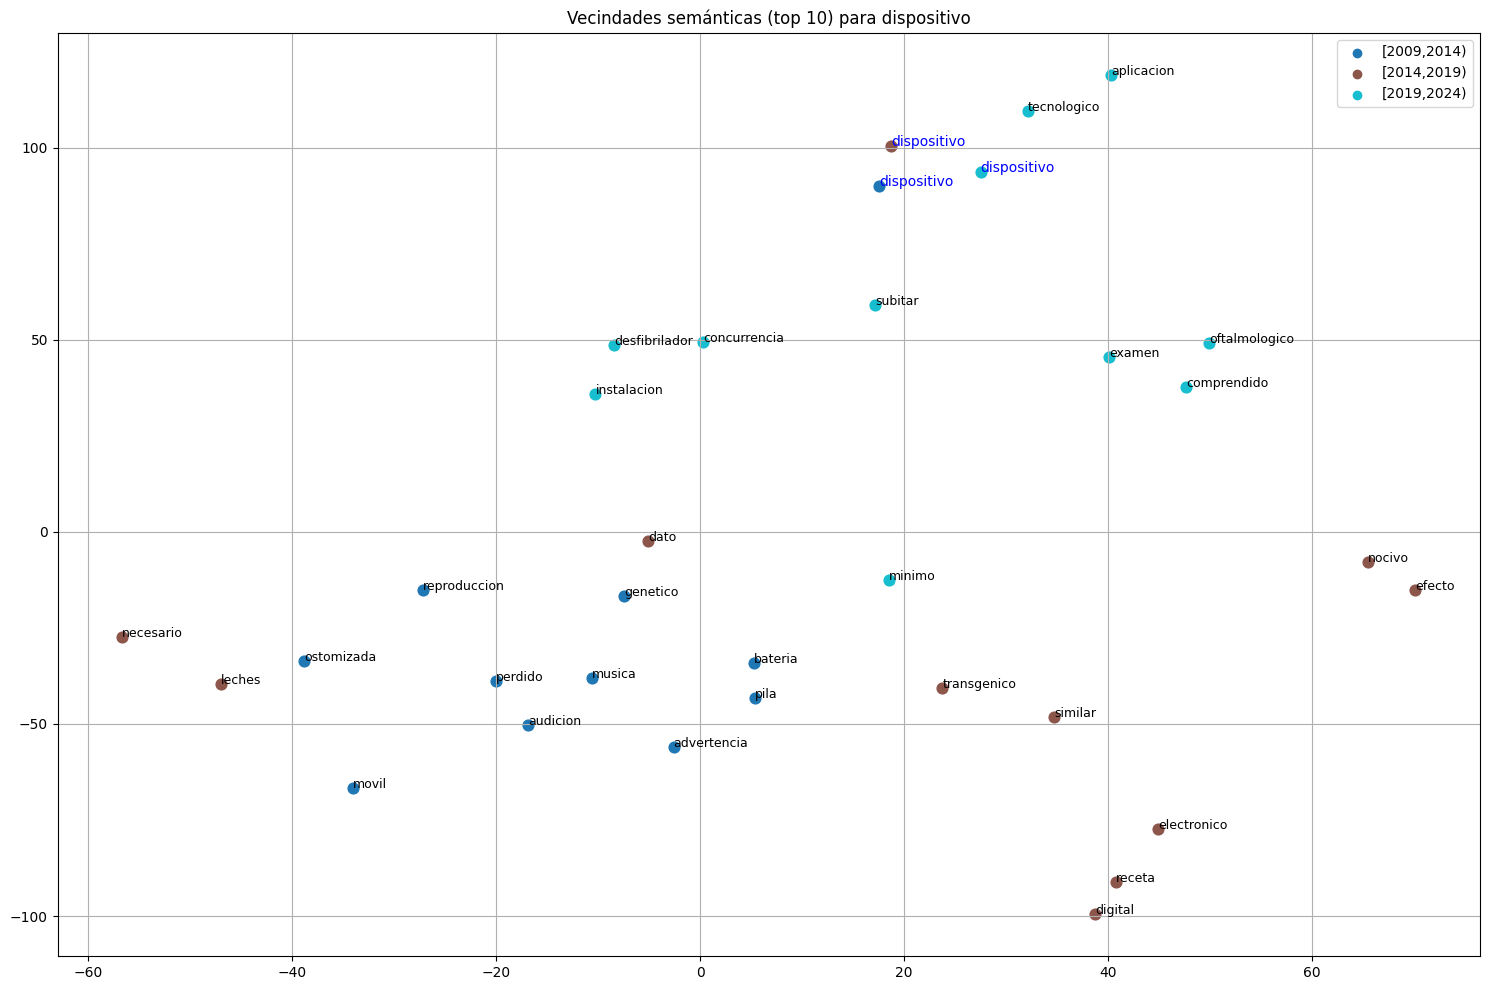

In [35]:
plot_neighbors_tsne('dispositivo', embeddings_by_period,alineados, [2009,2014,2019], top_k=10)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_7648\3491657529.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", len(periods))


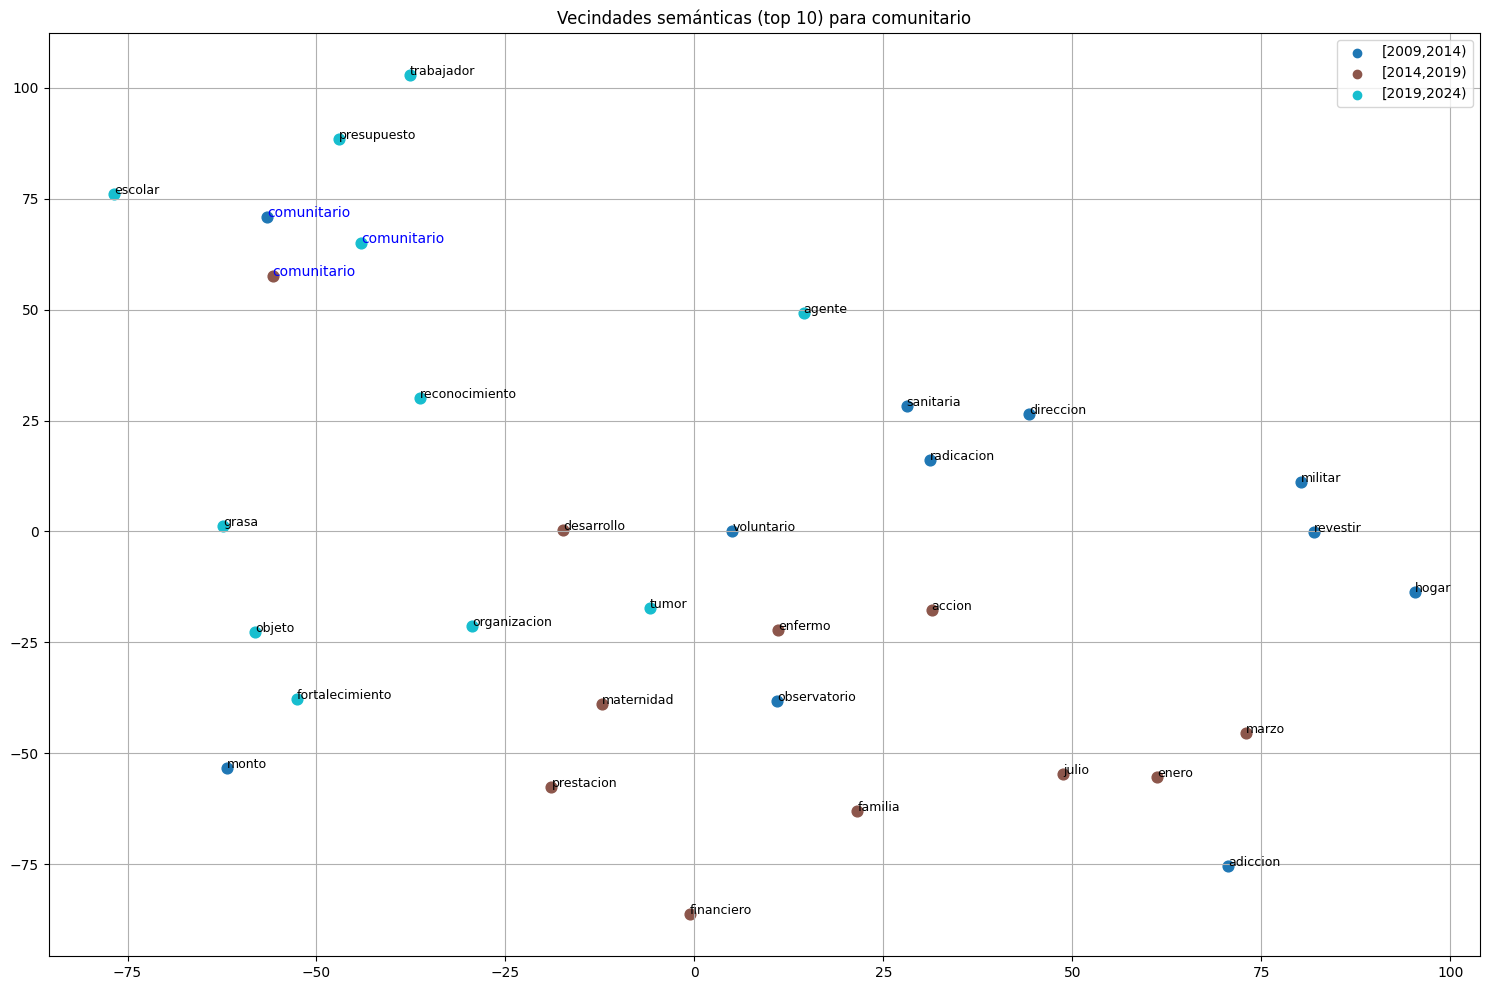

In [36]:
plot_neighbors_tsne('comunitario', embeddings_by_period,alineados, [2009,2014,2019], top_k=10)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_7648\3491657529.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", len(periods))


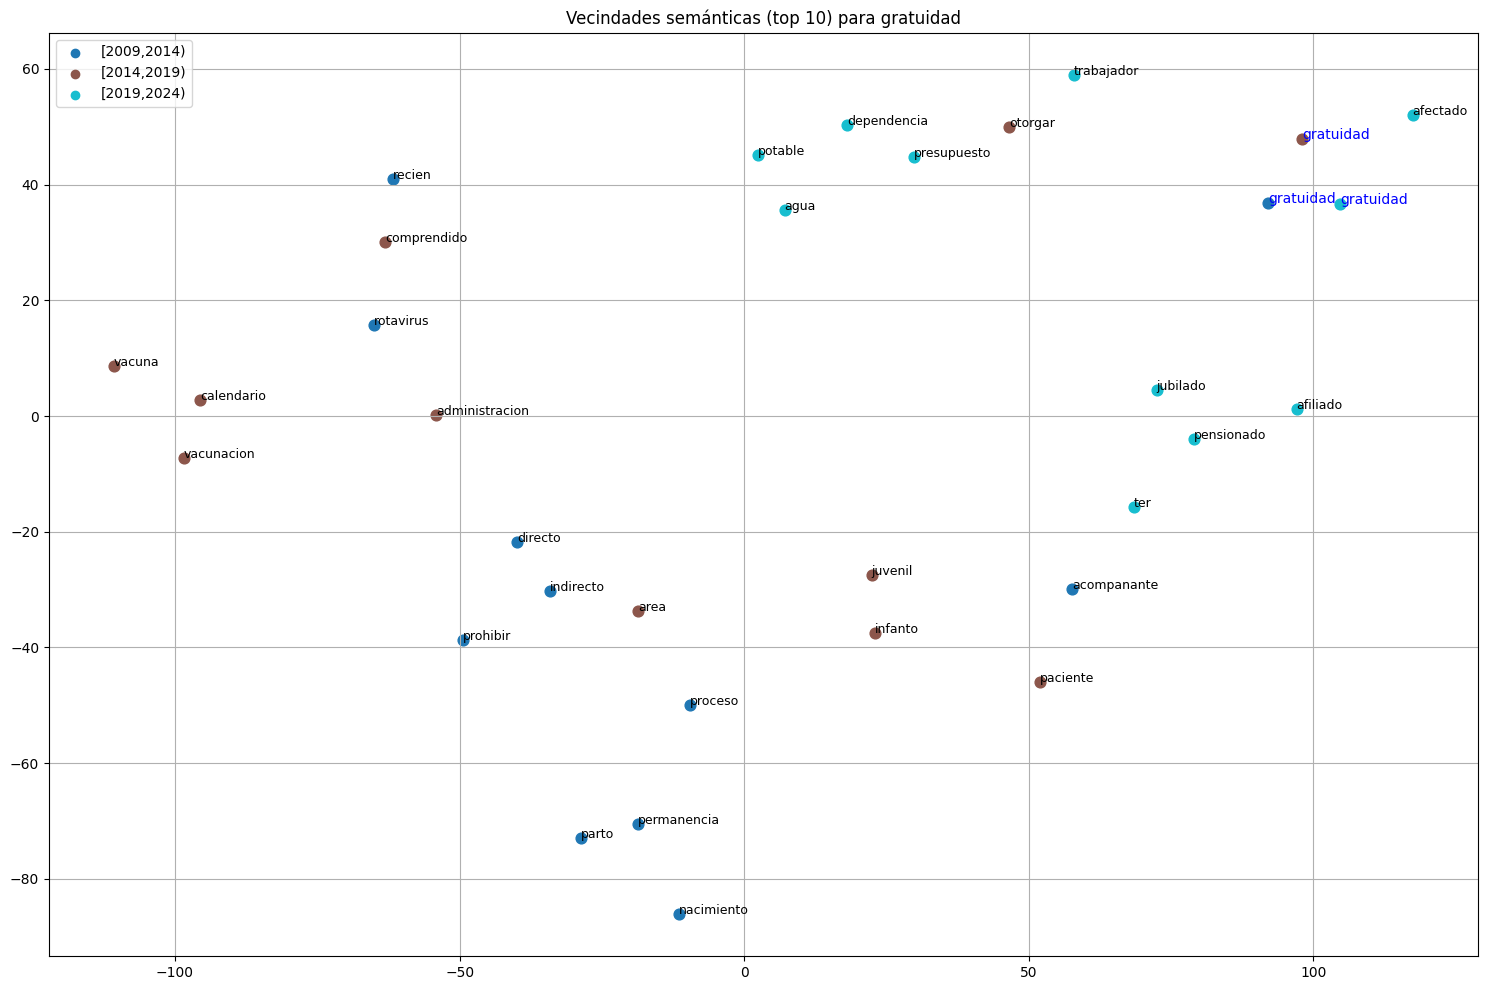

In [37]:
plot_neighbors_tsne('gratuidad', embeddings_by_period,alineados, [2009,2014,2019], top_k=10)


 Muerte súbita

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7648\3491657529.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", len(periods))


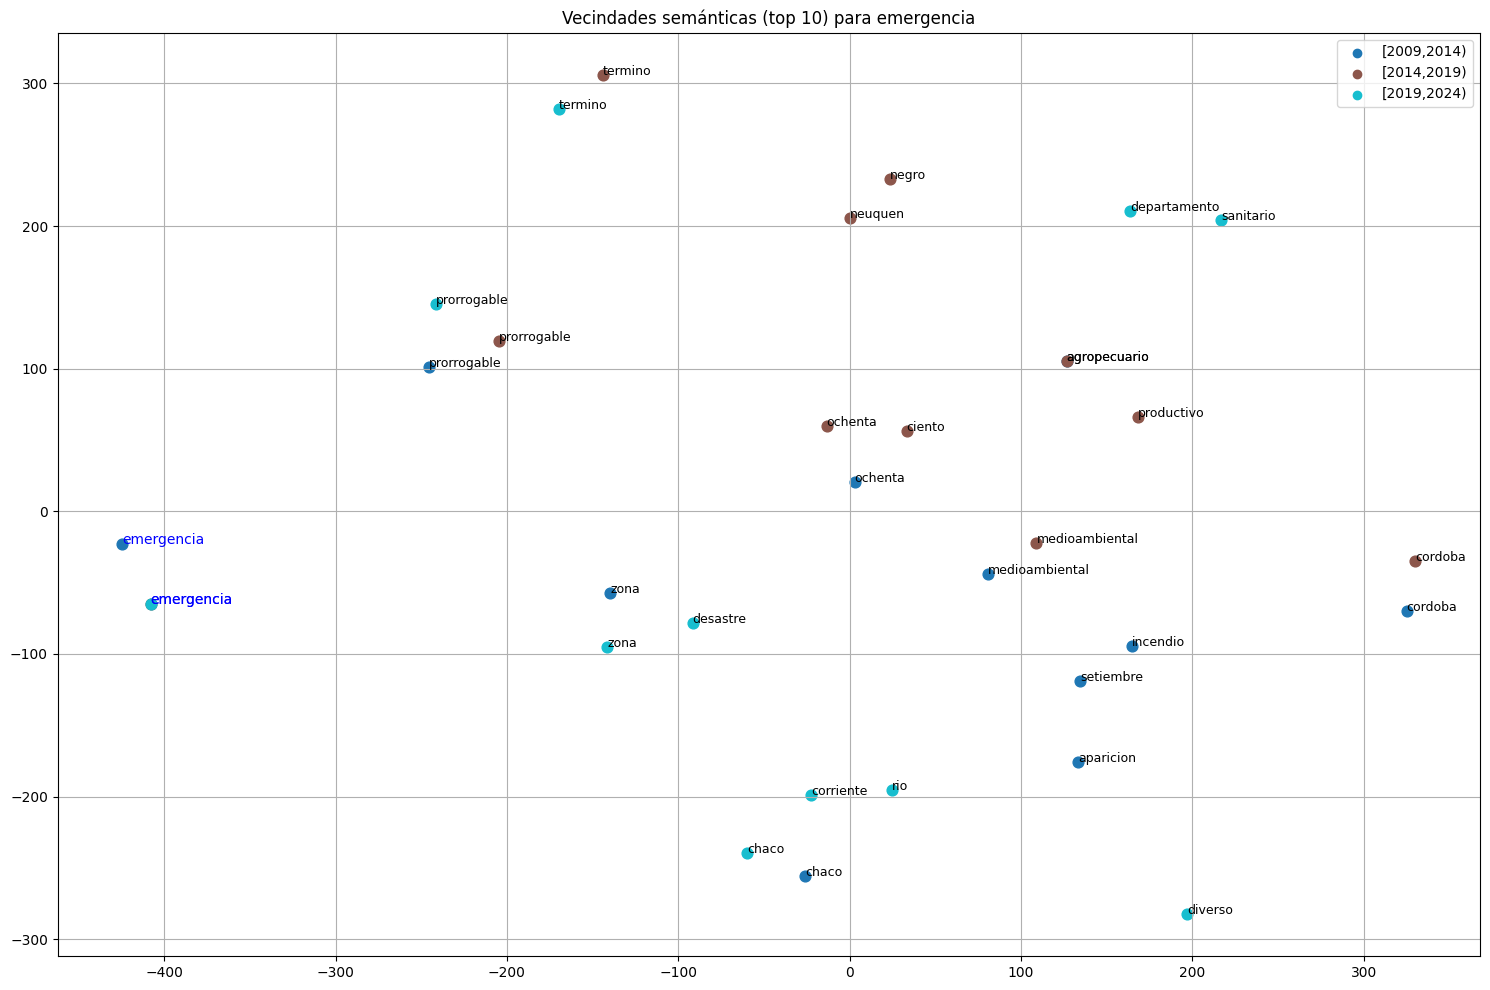

In [38]:
plot_neighbors_tsne('emergencia', embeddings_by_period,alineados, [2009,2014,2019], top_k=10)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7648\3491657529.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", len(periods))


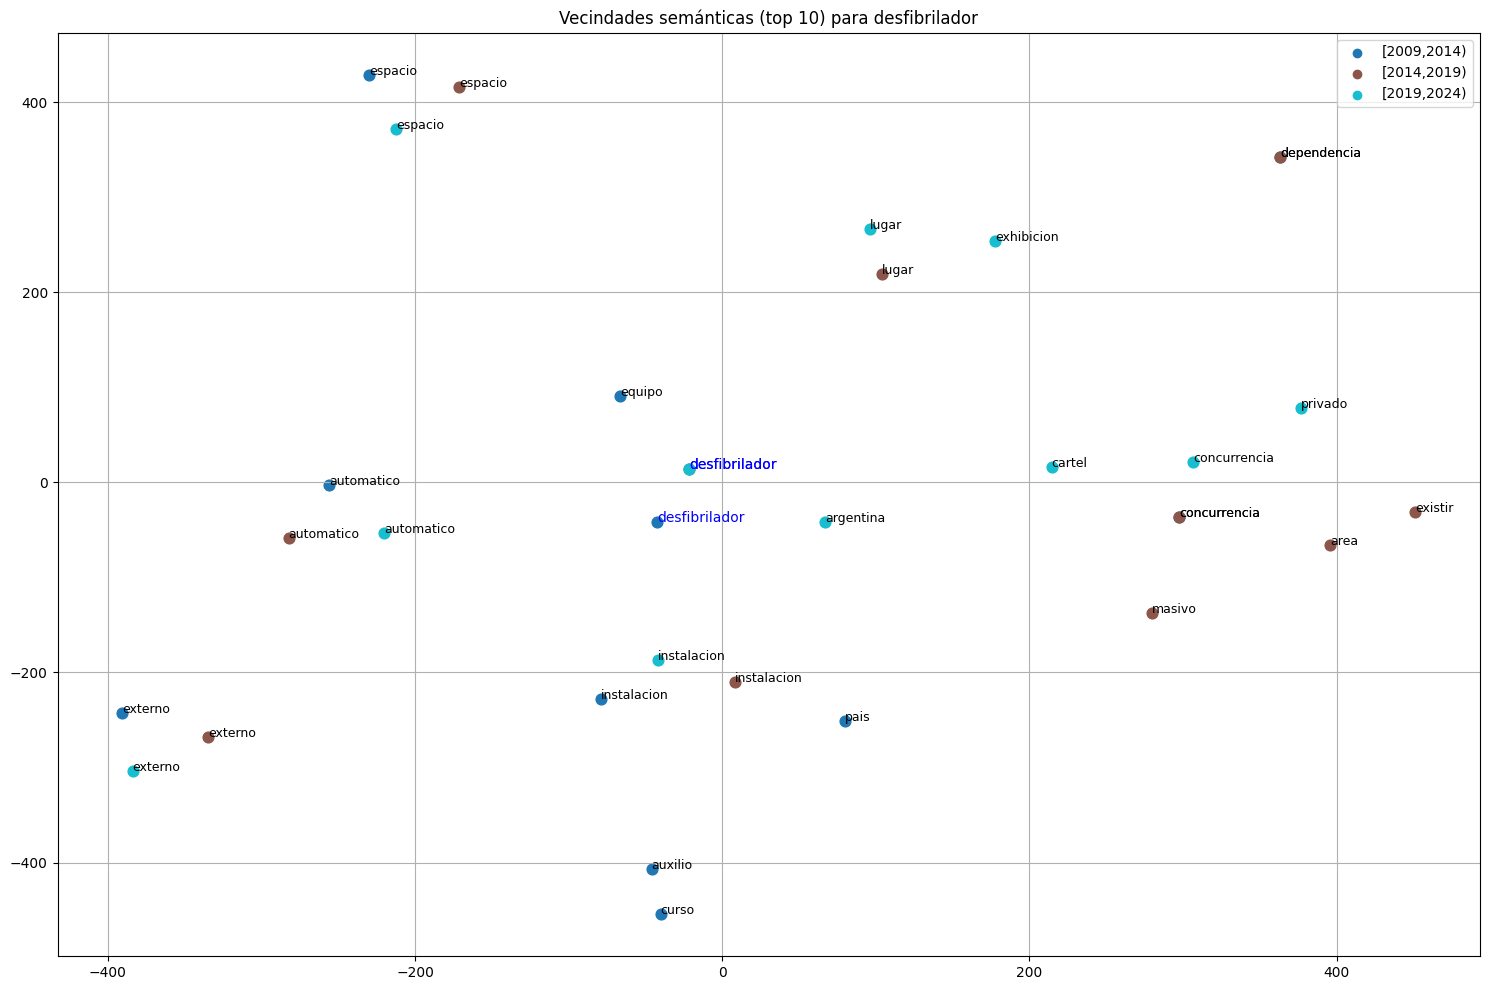

In [39]:
plot_neighbors_tsne('desfibrilador', embeddings_by_period,alineados, [2009,2014,2019], top_k=10)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7648\3491657529.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", len(periods))


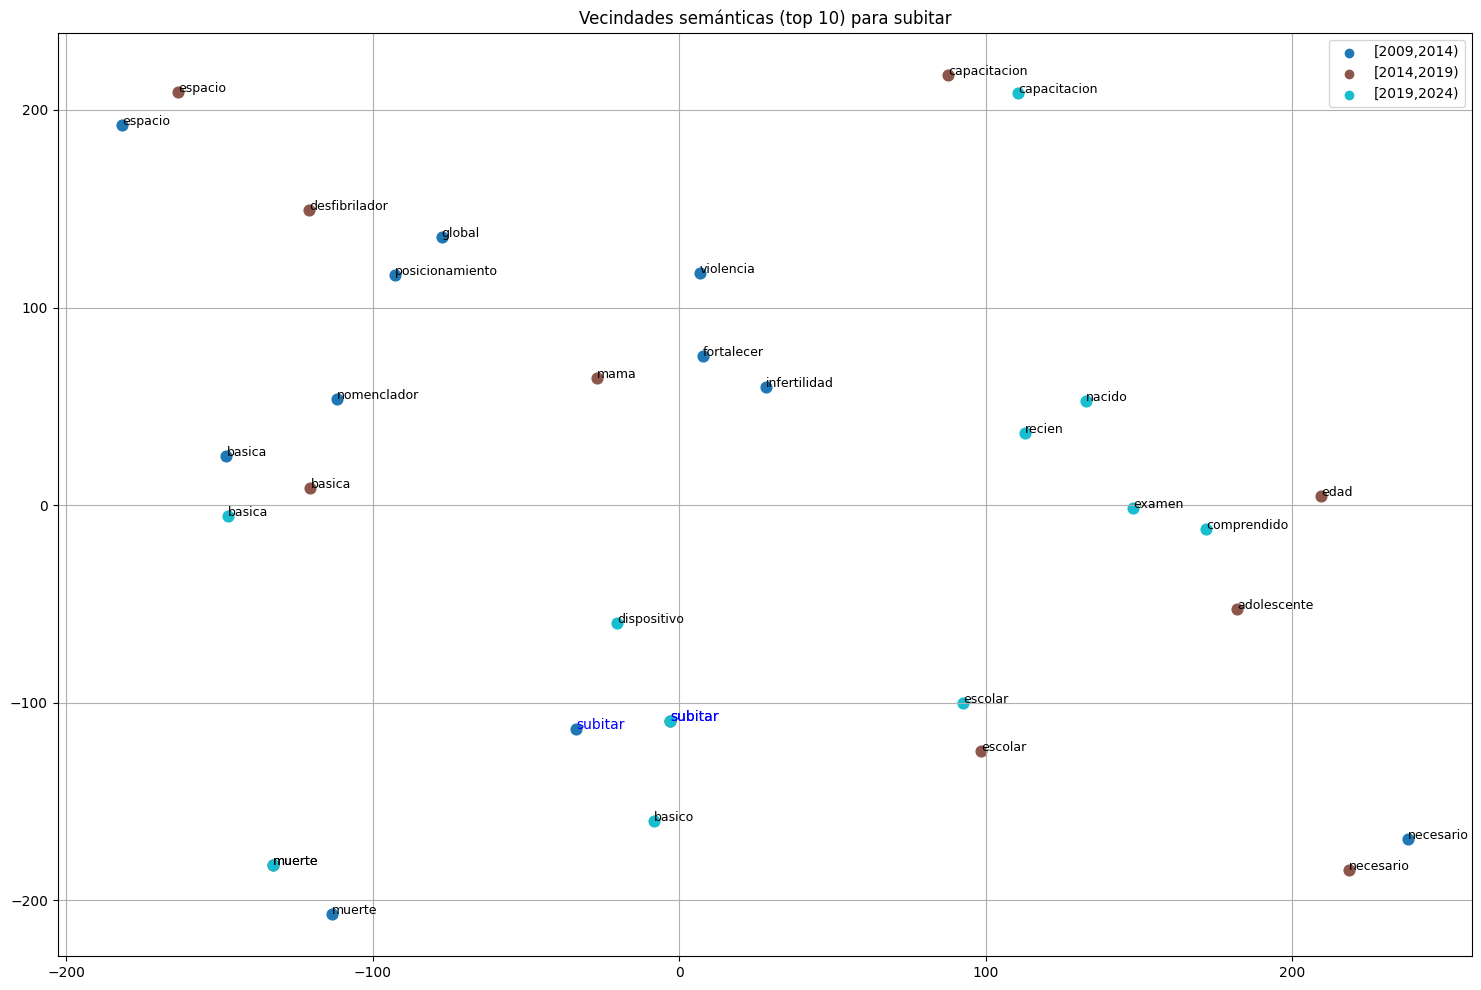

In [40]:
plot_neighbors_tsne('subitar', embeddings_by_period,alineados, [2009,2014,2019], top_k=10)

In [41]:
def_df = selected_topics_df[selected_topics_df.iteracion==0]
def_df = def_df[def_df.palabra=='desfibrilador']
def_df['vt1'] = def_df['top10_vecindad_t1'].apply(lambda x: [ peso[0] for peso in eval(x) ])
def_df['vt2'] = def_df['top10_vecindad_t2'].apply(lambda x: [ peso[0] for peso in eval(x) ])
def_df[['par_periodo','palabra','similaridad_semantica','vt1','vt2']]


,par_periodo,palabra,similaridad_semantica,vt1,vt2
49264,"(2014, 2019)",desfibrilador,0.833004,"[concurrencia, externo, existir, automatico, area, masivo, espacio, lugar, instalacion, dependencia]","[automatico, concurrencia, externo, lugar, instalacion, cartel, exhibicion, espacio, argentina, privado]"
51857,"(2009, 2014)",desfibrilador,0.866570,"[externo, espacio, automatico, dependencia, equipo, instalacion, auxilio, curso, concurrencia, pais]","[concurrencia, externo, existir, automatico, area, masivo, espacio, lugar, instalacion, dependencia]"


In [42]:
def_df = selected_topics_df[selected_topics_df.iteracion==0]
def_df = def_df[def_df.palabra=='subitar']
def_df['vt1'] = def_df['top10_vecindad_t1'].apply(lambda x: [ peso[0] for peso in eval(x) ])
def_df['vt2'] = def_df['top10_vecindad_t2'].apply(lambda x: [ peso[0] for peso in eval(x) ])
def_df[['par_periodo','palabra','similaridad_semantica','vt1','vt2']]


,par_periodo,palabra,similaridad_semantica,vt1,vt2
34126,"(2014, 2019)",subitar,0.713569,"[muerte, escolar, necesario, desfibrilador, basica, espacio, adolescente, edad, capacitacion, mama]","[muerte, escolar, nacido, recien, basica, basico, dispositivo, comprendido, examen, capacitacion]"
39217,"(2009, 2014)",subitar,0.746526,"[espacio, muerte, nomenclador, violencia, basica, fortalecer, necesario, posicionamiento, global, infertilidad]","[muerte, escolar, necesario, desfibrilador, basica, espacio, adolescente, edad, capacitacion, mama]"


Otros

In [43]:
plot_neighbors_tsne('aborto', embeddings_by_period,alineados, [2009,2014,2019], top_k=10)

 'aborto' no está en el vocabulario del período 2009
 'aborto' no está en el vocabulario del período 2014
 'aborto' no está en el vocabulario del período 2019
No hay datos suficientes para graficar.


C:\Users\Usuario\AppData\Local\Temp\ipykernel_7648\3491657529.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", len(periods))


C:\Users\Usuario\AppData\Local\Temp\ipykernel_7648\3491657529.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", len(periods))


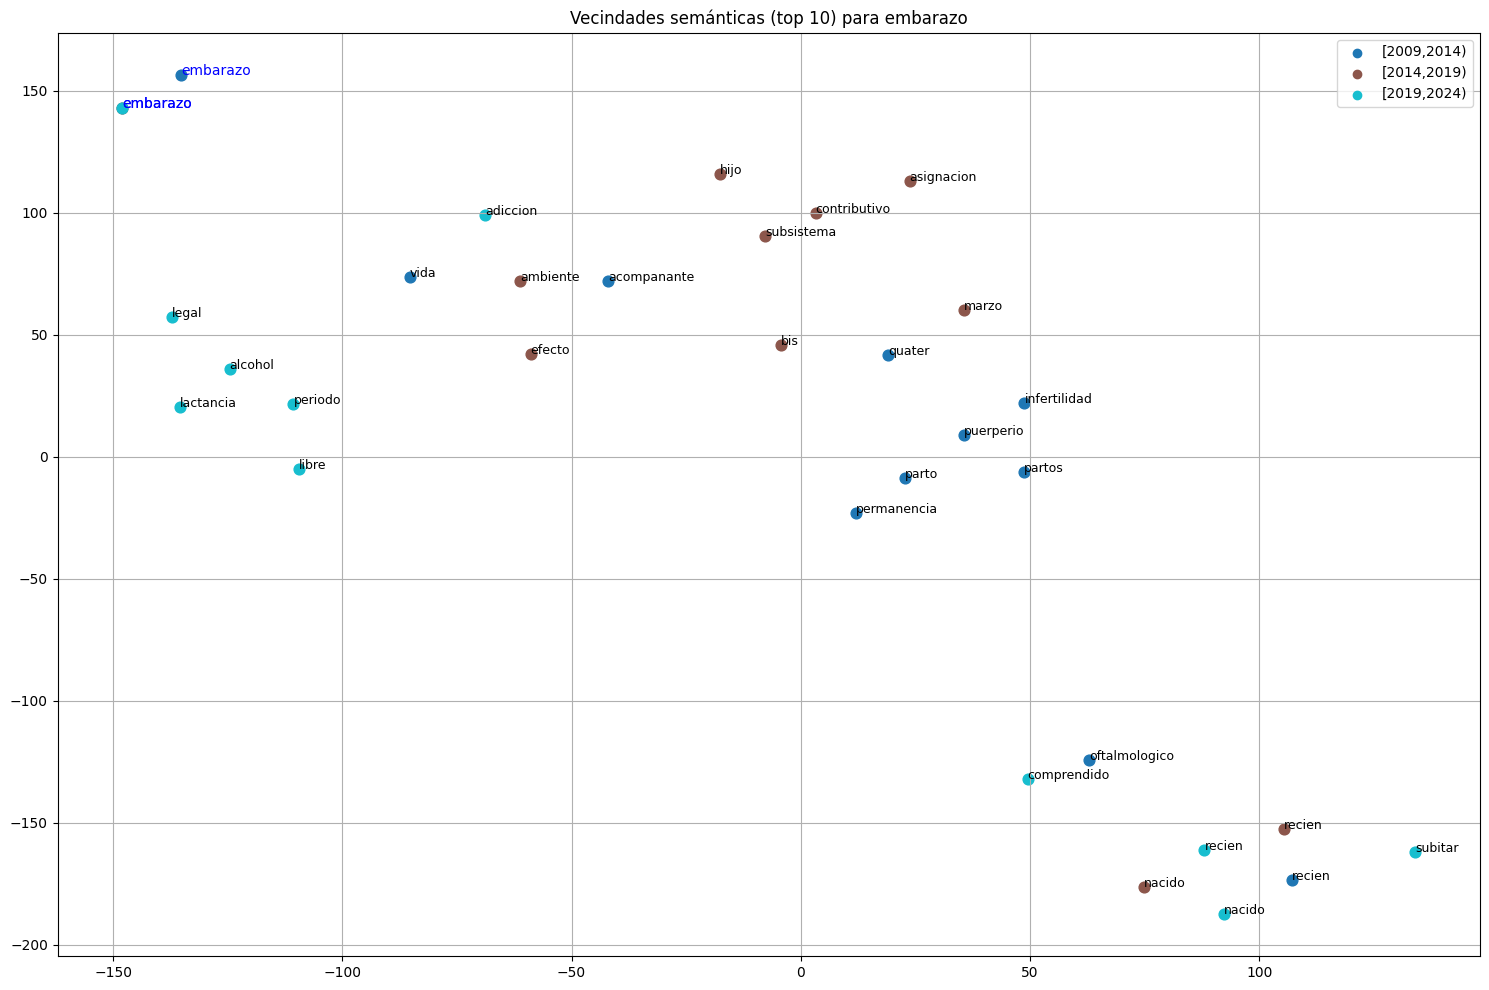

In [44]:
plot_neighbors_tsne('embarazo', embeddings_by_period,alineados, [2009,2014,2019], top_k=10)

#### Vectores medio de 50 iteraciones

In [46]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import cosine

def plot_neighbors_tsne2(palabra_objetivo, vectores_promedio_por_periodo, vecinos=5, perplexity=5, figsize=(15, 10)):
    """
    Visualiza con t-SNE el cambio semántico de una palabra y sus vecinos a través de períodos.

    Parameters:
    - palabra_objetivo: str, palabra a analizar
    - vectores_promedio_por_periodo: dict. Ej: {2019: {'palabra': vector, ...}, 2014: {...}, ...}
    - vecinos: int, cantidad de vecinos semánticos a mostrar por período
    - perplexity: int, parámetro de t-SNE
    - figsize: tuple, tamaño del gráfico
    """
    X = []
    labels = []
    colores = []

    for periodo, vectores in vectores_promedio_por_periodo.items():
        if palabra_objetivo not in vectores:
            continue

        # Vector de la palabra objetivo
        X.append(vectores[palabra_objetivo])
        labels.append(f'{palabra_objetivo}')
        colores.append(periodo)

        # Vecinos por similitud coseno
        vecinos_similares = sorted(
            vectores.items(),
            key=lambda kv: cosine(kv[1], vectores[palabra_objetivo])
        )[1:vecinos+1]

        for vecino, vec in vecinos_similares:
            X.append(vec)
            labels.append(f'{vecino}')
            colores.append(periodo)

    if not X:
        print(f' La palabra "{palabra_objetivo}" no se encuentra en ningún período.')
        return

    # t-SNE
    X = np.array(X)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    X_2d = tsne.fit_transform(X)

    # Mapa de colores por período
    colores_unicos = sorted(set(colores))
    cmap = plt.cm.get_cmap('Set1', len(colores_unicos))
    periodo_color = {p: cmap(i) for i, p in enumerate(colores_unicos)}

    # Gráfico
    plt.figure(figsize=figsize)
    for i, label in enumerate(labels):
        x, y = X_2d[i]
        periodo = colores[i]
        plt.scatter(x, y, c=[periodo_color[periodo]], s=80 if label.startswith(palabra_objetivo) else 40)
        plt.text(x+0.2, y, label, fontsize=8)

    # Leyenda
    handles = [plt.Line2D([0], [0], marker='o', color='w', label=str(p),
                          markerfacecolor=periodo_color[p], markersize=10)
               for p in colores_unicos]

    plt.legend(handles=handles, title='Período')
    plt.title(f'Vecinos semánticos de "{palabra_objetivo}" por período (t-SNE)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7648\3491657529.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", len(periods))


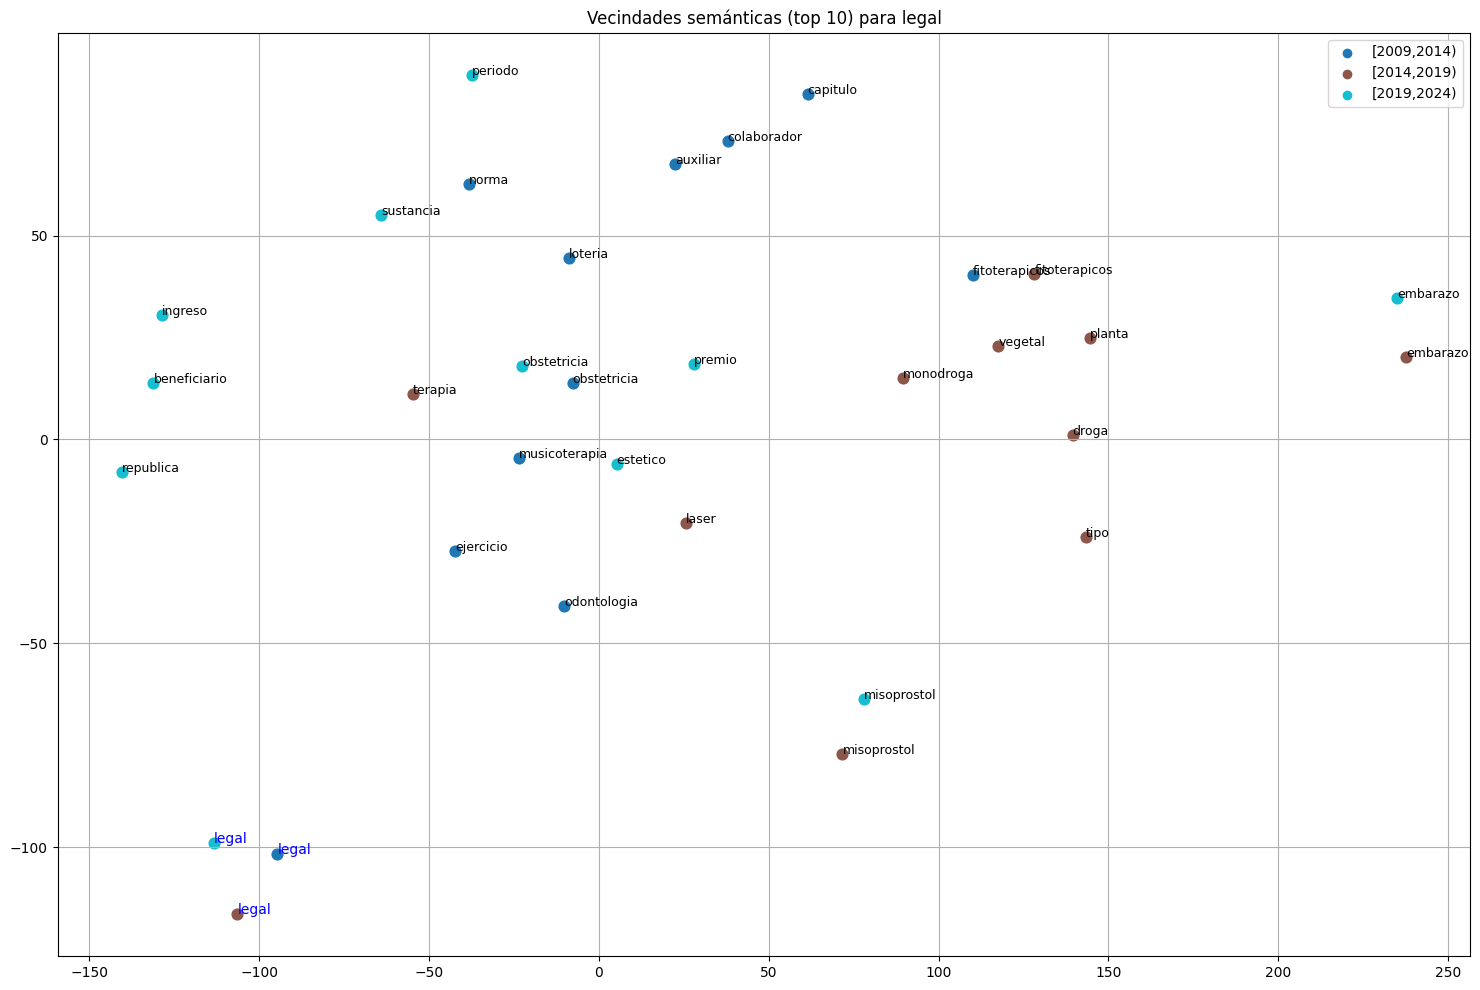

In [47]:

plot_neighbors_tsne('legal', embeddings_by_period,alineados, [2009,2014,2019], top_k=10)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7648\3246133751.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1', len(colores_unicos))


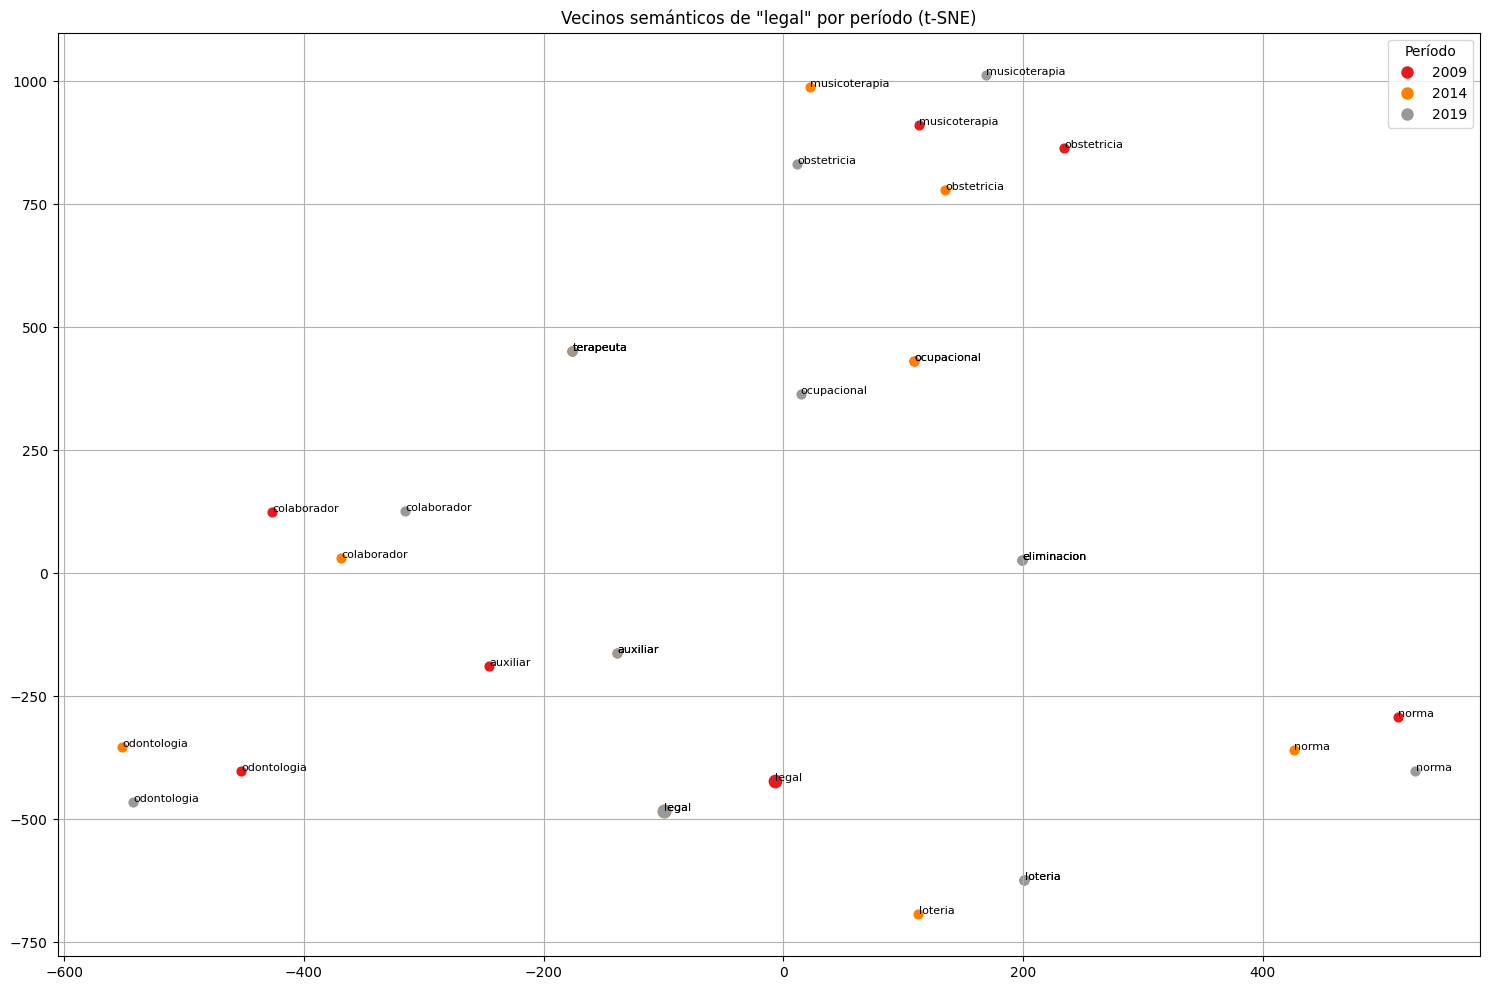

In [48]:
plot_neighbors_tsne2('legal', vectores_promedio, vecinos=10)


### Chat GPT

#### Breve historia del sistema argentino de salud entre 2009 a 2023

Destacando los principales cambios, políticas y desafíos en ese período:

**2009-2015: Ampliación de cobertura y enfoque en salud pública**
* Programa Nacer (iniciado antes) se transformó en Programa SUMAR (2012), ampliando la cobertura sanitaria gratuita a población sin obra social, especialmente niños, embarazadas y adultos hasta 64 años.

* Se fortalecieron las políticas de atención primaria, la distribución gratuita de medicamentos esenciales y el control de enfermedades crónicas.

* Ley Nacional de Salud Mental (2010): marcó un cambio paradigmático hacia una atención centrada en la comunidad, con foco en derechos humanos.

* Inversión en infraestructura y en redes de servicios provinciales, aunque con desigualdades persistentes entre regiones.

**2016-2019: Intento de reformas estructurales y retrocesos por la crisis**

* Lanzamiento de la Cobertura Universal de Salud (CUS) en 2016, con el objetivo de mejorar el acceso de personas sin cobertura formal; sin embargo, tuvo una implementación limitada.

* La crisis económica (inflación, devaluación, recorte del gasto) afectó recursos para salud pública y programas nacionales.

* Tensiones con obras sociales y prepagas por regulaciones, deudas y aranceles.

* En 2018, debate parlamentario por la legalización del aborto generó una movilización social histórica, aunque fue rechazado por el Senado.

**2020-2023: Pandemia, legalización del aborto y digitalización**
* COVID-19 (2020-2021) puso al sistema bajo gran presión: se ampliaron camas, respiradores, se contrató personal y se distribuyeron recursos federales.

* Se desarrolló un plan nacional de vacunación masivo y gratuito, con campañas públicas y centros de vacunación en todo el país.

* En diciembre de 2020 se aprobó la Ley 27.610 de Interrupción Voluntaria del Embarazo, garantizando el derecho a acceder a un aborto legal y seguro hasta la semana 14.

* Se fortaleció la telemedicina y se impulsó la digitalización de historiales clínicos, aunque de manera desigual según la provincia.

* En 2022-2023, el sistema volvió a enfrentar restricciones presupuestarias por la crisis económica, con reclamos de trabajadores de salud, atraso en pagos a proveedores y conflicto con prepagas por aumentos de cuotas y regulación estatal.

#### Conclusión
El sistema de salud argentino entre 2009 y 2023 mostró avances importantes en derechos y cobertura, especialmente con programas públicos y leyes clave (salud mental, aborto). Pero también atravesó crisis económicas y desafíos estructurales que afectaron la calidad y equidad del acceso, manteniéndose como un sistema fragmentado y desigual, con fuerte dependencia de decisiones políticas nacionales y provinciales.

# Anexo

#### Como detectar cambios liguistico con chatgpt

Detectar cambios lingüísticos con ChatGPT u otros modelos de lenguaje puede hacerse de varias formas, dependiendo de qué tipo de cambio te interesa (léxico, semántico, sintáctico, etc.).

* Comparación sincrónica: simular diferentes “épocas” pidiéndole al modelo que hable como si fuera de cierto año:

🗣️ Prompt:
“¿Cómo se usaba la palabra ‘cuidar’ en el contexto de salud pública en Argentina en 2010?”
vs.
“¿Cómo se usa la palabra ‘cuidar’ en el contexto de salud pública en Argentina en 2023?”

* Análisis con embeddings + ChatGPT

Asistente para interpretar cambios de significado basados en embeddings entrenados por año. Ejemplo:
Entrenás vectores (word embeddings) para distintos años. Medís distancia o cambio de contexto de ciertas palabras clave. Usás ChatGPT para ayudarte a interpretar esos cambios

🔍 Prompt:
“En 2010, la palabra ‘prevención’ estaba más cerca de ‘vacuna’, ‘campaña’, ‘dengue’. En 2023, está más cerca de ‘cuidado’, ‘género’, ‘territorio’. ¿Qué tipo de cambio semántico puede estar ocurriendo?”